In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report
import umap
import hdbscan
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
import pandas as pd
from scipy import stats
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

class EnhancedAnomalyDetectionSystem:
    """Enhanced anomaly detection system with risk categorization and accuracy evaluation."""
    
    def __init__(self, custom_model_path: str, use_standard_scaler: bool = True):
        """Initialize the anomaly detection system."""
        self.mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
        self.custom_model = load_model(custom_model_path)
        self.custom_feature_model = Model(inputs=self.custom_model.input, 
                                        outputs=self.custom_model.layers[-2].output)
        
        self.use_standard_scaler = use_standard_scaler
        self.scaler = StandardScaler() if use_standard_scaler else None
        self.umap_model = None
        self.cluster_centers = {}
        self.cluster_stats = {}
        
        # Risk categorization thresholds
        self.risk_thresholds = {
            'distance': {'high': 60, 'medium': 35},
            'confidence': {'high': 0.3, 'medium': 0.6},
            'percentile_distance': {'high': 99, 'medium': 95}
        }
        
    def extract_features(self, img_path: str) -> np.ndarray:
        """Extract combined features from both models."""
        try:
            img = image.load_img(img_path, target_size=(224, 224))
            x = image.img_to_array(img)
            x = preprocess_input(x)
            x = np.expand_dims(x, axis=0)

            feat1 = self.mobilenet_model.predict(x, verbose=0)[0]
            feat2 = self.custom_feature_model.predict(x, verbose=0)[0]
            combined_features = np.concatenate([feat1, feat2])
            
            return combined_features
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            return None
    
    def extract_features_batch(self, image_folder: str) -> Tuple[np.ndarray, List[str]]:
        """Extract features from all images in a folder."""
        print(f"Extracting features from {image_folder}...")
        features = []
        filenames = []
        
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        
        for fname in os.listdir(image_folder):
            if fname.lower().endswith(valid_extensions):
                path = os.path.join(image_folder, fname)
                feat = self.extract_features(path)
                if feat is not None:
                    features.append(feat)
                    filenames.append(fname)
        
        features = np.array(features, dtype=np.float64)
        
        # Apply scaling if enabled
        if self.use_standard_scaler and len(features) > 0:
            features = self.scaler.fit_transform(features)
            
        print(f"✅ Extracted features for {len(filenames)} images.")
        return features, filenames
    
    def find_optimal_clusters(self, features: np.ndarray, max_k: int = 10) -> int:
        """Find optimal number of clusters using silhouette score."""
        if len(features) < 4:
            return 2
            
        silhouette_scores = []
        k_range = range(2, min(max_k + 1, len(features)))
        
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(features)
            score = silhouette_score(features, labels)
            silhouette_scores.append(score)
        
        optimal_k = k_range[np.argmax(silhouette_scores)]
        print(f"Optimal number of clusters: {optimal_k} (silhouette score: {max(silhouette_scores):.3f})")
        return optimal_k
    
    def fit_clustering_models(self, features: np.ndarray, filenames: List[str]) -> Dict:
        """Fit UMAP and HDBSCAN models and compute cluster statistics."""
        print("Running UMAP dimensionality reduction...")
        self.umap_model = umap.UMAP(
            n_neighbors=min(15, len(features) // 3),
            min_dist=0.1,
            n_components=2,
            metric='cosine',
            random_state=42
        )
        umap_embeddings = self.umap_model.fit_transform(features)
        
        print("Running HDBSCAN clustering...")
        # Adaptive min_cluster_size based on dataset size
        min_cluster_size = max(3, len(features) // 20)
        hdb = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=max(1, min_cluster_size // 2)
        )
        hdb_labels = hdb.fit_predict(umap_embeddings)
        
        # Compute cluster statistics
        self._compute_cluster_statistics(features, hdb_labels)
        
        return {
            'umap_embeddings': umap_embeddings,
            'hdb_labels': hdb_labels,
            'hdb_model': hdb
        }
    
    def _compute_cluster_statistics(self, features: np.ndarray, labels: np.ndarray):
        """Compute comprehensive cluster statistics."""
        unique_labels = np.unique(labels)
        inlier_features = features[labels != -1]
        inlier_labels = labels[labels != -1]
        
        for label in unique_labels:
            if label == -1:
                continue
                
            cluster_features = inlier_features[inlier_labels == label]
            center = cluster_features.mean(axis=0)
            
            # Compute various statistics
            distances_to_center = [np.linalg.norm(feat - center) for feat in cluster_features]
            
            self.cluster_centers[label] = center
            self.cluster_stats[label] = {
                'center': center,
                'size': len(cluster_features),
                'mean_distance': np.mean(distances_to_center),
                'std_distance': np.std(distances_to_center),
                'percentile_90': np.percentile(distances_to_center, 90),
                'percentile_95': np.percentile(distances_to_center, 95),
                'percentile_99': np.percentile(distances_to_center, 99)
            }
        
        print(f"Computed statistics for {len(self.cluster_centers)} clusters.")
    
    def calculate_risk_score(self, min_distance: float, max_confidence: float, 
                           closest_cluster: int) -> float:
        """Calculate a composite risk score between 0-100."""
        # Distance component (0-40 points)
        if min_distance > self.risk_thresholds['distance']['high']:
            distance_score = 40
        elif min_distance > self.risk_thresholds['distance']['medium']:
            distance_score = 25
        else:
            distance_score = max(0, (min_distance / self.risk_thresholds['distance']['medium']) * 25)
        
        # Confidence component (0-40 points)
        if max_confidence < self.risk_thresholds['confidence']['high']:
            confidence_score = 40
        elif max_confidence < self.risk_thresholds['confidence']['medium']:
            confidence_score = 25
        else:
            confidence_score = max(0, 25 - ((max_confidence - 0.6) / 0.4) * 25)
        
        # Cluster-based component (0-20 points)
        cluster_score = 0
        if closest_cluster in self.cluster_stats:
            cluster_distance_percentile = self._get_distance_percentile(min_distance, closest_cluster)
            if cluster_distance_percentile > 99:
                cluster_score = 20
            elif cluster_distance_percentile > 95:
                cluster_score = 15
            elif cluster_distance_percentile > 90:
                cluster_score = 10
            else:
                cluster_score = max(0, (cluster_distance_percentile / 90) * 10)
        
        return min(100, distance_score + confidence_score + cluster_score)
    
    def _get_distance_percentile(self, distance: float, cluster_label: int) -> float:
        """Get the percentile of distance within the cluster."""
        if cluster_label not in self.cluster_stats:
            return 100
        
        stats = self.cluster_stats[cluster_label]
        if distance > stats['percentile_99']:
            return 99.5
        elif distance > stats['percentile_95']:
            return 97
        elif distance > stats['percentile_90']:
            return 92
        else:
            # Rough approximation for lower percentiles
            return min(90, (distance / stats['mean_distance']) * 50)
    
    def categorize_risk(self, risk_score: float) -> str:
        """Categorize risk based on score."""
        if risk_score >= 70:
            return "High"
        elif risk_score >= 40:
            return "Medium"
        else:
            return "Low"
    
    def detect_anomalies_advanced(self, img_path: str) -> Dict:
        """Advanced anomaly detection with risk categorization."""
        features = self.extract_features(img_path)
        if features is None:
            return {'error': 'Failed to extract features'}
        
        if self.use_standard_scaler and self.scaler:
            features = self.scaler.transform(features.reshape(1, -1))[0]
        
        # Get prediction confidence
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)
        prediction = self.custom_model.predict(x, verbose=0)[0]
        max_confidence = np.max(prediction)
        predicted_class = np.argmax(prediction)
        
        # Distance-based detection
        distances = {}
        for label, stats in self.cluster_stats.items():
            center = stats['center']
            distance = np.linalg.norm(features - center)
            distances[label] = distance
        
        min_distance = min(distances.values()) if distances else float('inf')
        closest_cluster = min(distances, key=distances.get) if distances else -1
        
        # Calculate risk score and category
        risk_score = self.calculate_risk_score(min_distance, max_confidence, closest_cluster)
        risk_category = self.categorize_risk(risk_score)
        
        # Traditional anomaly detection
        is_anomaly = (
            risk_score >= 40 or  # Medium risk or higher
            max_confidence < 0.2 or 
            min_distance > 60
        )
        
        return {
            'min_distance': min_distance,
            'closest_cluster': closest_cluster,
            'max_confidence': max_confidence,
            'predicted_class': predicted_class,
            'risk_score': risk_score,
            'risk_category': risk_category,
            'is_anomaly': is_anomaly,
            'all_distances': distances
        }
    
    def evaluate_folder(self, folder_path: str, ground_truth_labels: Optional[List[str]] = None) -> List[Dict]:
        """Evaluate all images in a folder for anomalies."""
        print(f"\nEvaluating folder: {folder_path}")
        
        if not os.path.exists(folder_path):
            print(f"⚠️ ERROR: Folder not found.")
            return []
        
        results = []
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        
        filenames = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
        
        for i, fname in enumerate(filenames):
            path = os.path.join(folder_path, fname)
            result = self.detect_anomalies_advanced(path)
            if 'error' not in result:
                result['filename'] = fname
                if ground_truth_labels and i < len(ground_truth_labels):
                    result['ground_truth'] = ground_truth_labels[i]
                results.append(result)
        
        print(f"✅ Evaluated {len(results)} images.")
        return results
    
    def calculate_accuracy_by_category(self, results: List[Dict]) -> Dict:
        """Calculate accuracy metrics for each risk category."""
        if not results or 'ground_truth' not in results[0]:
            print("⚠️ Ground truth labels not available for accuracy calculation.")
            return {}
        
        categories = ['High', 'Medium', 'Low']
        accuracy_metrics = {}
        
        for category in categories:
            category_results = [r for r in results if r['risk_category'] == category]
            if not category_results:
                accuracy_metrics[category] = {
                    'count': 0,
                    'accuracy': 0,
                    'precision': 0,
                    'recall': 0,
                    'f1_score': 0
                }
                continue
            
            # Calculate metrics
            predictions = [r['is_anomaly'] for r in category_results]
            ground_truth = [r['ground_truth'] == 'anomaly' for r in category_results]
            
            if len(set(ground_truth)) > 1:  # Both classes present
                from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
                
                accuracy = accuracy_score(ground_truth, predictions)
                precision = precision_score(ground_truth, predictions, zero_division=0)
                recall = recall_score(ground_truth, predictions, zero_division=0)
                f1 = f1_score(ground_truth, predictions, zero_division=0)
            else:
                # Only one class present
                accuracy = sum(p == g for p, g in zip(predictions, ground_truth)) / len(predictions)
                precision = recall = f1 = 0 if accuracy == 0 else 1
            
            accuracy_metrics[category] = {
                'count': len(category_results),
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'correct_predictions': sum(p == g for p, g in zip(predictions, ground_truth))
            }
        
        return accuracy_metrics
    
    def generate_comprehensive_report(self, results: List[Dict], folder_name: str, 
                                    accuracy_metrics: Dict = None) -> pd.DataFrame:
        """Generate comprehensive evaluation report with risk categorization."""
        if not results:
            print(f"No results for {folder_name}")
            return pd.DataFrame()
        
        df = pd.DataFrame(results)
        
        total_count = len(results)
        anomaly_count = df['is_anomaly'].sum()
        
        # Risk category analysis
        risk_counts = df['risk_category'].value_counts()
        
        print(f"\n=== COMPREHENSIVE REPORT: {folder_name} ===")
        print(f"Total Images: {total_count}")
        print(f"{'='*60}")
        print(f"RISK CATEGORIZATION:")
        print(f"  High Risk:   {risk_counts.get('High', 0):3d} ({risk_counts.get('High', 0)/total_count*100:5.1f}%)")
        print(f"  Medium Risk: {risk_counts.get('Medium', 0):3d} ({risk_counts.get('Medium', 0)/total_count*100:5.1f}%)")
        print(f"  Low Risk:    {risk_counts.get('Low', 0):3d} ({risk_counts.get('Low', 0)/total_count*100:5.1f}%)")
        print(f"{'='*60}")
        print(f"Total Detected Anomalies: {anomaly_count} ({anomaly_count/total_count*100:.1f}%)")
        
        # Accuracy metrics by category
        if accuracy_metrics:
            print(f"\nACCURACY BY RISK CATEGORY:")
            print(f"{'Category':<10} {'Count':<8} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
            print(f"{'-'*70}")
            for category, metrics in accuracy_metrics.items():
                if metrics['count'] > 0:
                    print(f"{category:<10} {metrics['count']:<8} {metrics['accuracy']:<10.3f} "
                          f"{metrics['precision']:<10.3f} {metrics['recall']:<10.3f} {metrics['f1_score']:<10.3f}")
        
        # Statistical summary
        print(f"\nSTATISTICAL SUMMARY:")
        print(f"Risk Score Statistics:")
        print(f"  Mean: {df['risk_score'].mean():.2f}")
        print(f"  Std:  {df['risk_score'].std():.2f}")
        print(f"  90th percentile: {df['risk_score'].quantile(0.90):.2f}")
        
        print(f"Distance Statistics:")
        print(f"  Mean: {df['min_distance'].mean():.2f}")
        print(f"  Std:  {df['min_distance'].std():.2f}")
        print(f"  95th percentile: {df['min_distance'].quantile(0.95):.2f}")
        
        print(f"Confidence Statistics:")
        print(f"  Mean: {df['max_confidence'].mean():.3f}")
        print(f"  Std:  {df['max_confidence'].std():.3f}")
        print(f"  5th percentile: {df['max_confidence'].quantile(0.05):.3f}")
        
        return df
    
    def visualize_results_enhanced(self, original_embeddings: np.ndarray, original_labels: np.ndarray,
                                 anomaly_results: List[Dict] = None, inlier_results: List[Dict] = None,
                                 anomaly_folder: str = None, inlier_folder: str = None):
        """Create enhanced visualization with risk categorization."""
        fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(18, 20))
        
        # Plot 1: Original clustering
        scatter1 = ax1.scatter(original_embeddings[:, 0], original_embeddings[:, 1], 
                              c=original_labels, cmap='viridis', s=30, alpha=0.7)
        ax1.set_title("Original HDBSCAN Clustering", fontsize=14, fontweight='bold')
        ax1.set_xlabel("UMAP Dimension 1")
        ax1.set_ylabel("UMAP Dimension 2")
        ax1.grid(True, alpha=0.3)
        plt.colorbar(scatter1, ax=ax1)
        
        # Plot 2: Risk-based visualization
        ax2.scatter(original_embeddings[:, 0], original_embeddings[:, 1], 
                   c=original_labels, cmap='viridis', s=20, alpha=0.3, label='Original Data')
        
        # Color mapping for risk categories
        risk_colors = {'High': 'red', 'Medium': 'orange', 'Low': 'yellow'}
        risk_markers = {'High': 'X', 'Medium': 's', 'Low': 'o'}
        
        if anomaly_results and anomaly_folder:
            for category in ['High', 'Medium', 'Low']:
                category_results = [r for r in anomaly_results if r['risk_category'] == category]
                if not category_results:
                    continue
                    
                features = []
                for result in category_results:
                    path = os.path.join(anomaly_folder, result['filename'])
                    feat = self.extract_features(path)
                    if feat is not None:
                        if self.use_standard_scaler and self.scaler:
                            feat = self.scaler.transform(feat.reshape(1, -1))[0]
                        features.append(feat)
                
                if features:
                    embeddings = self.umap_model.transform(np.array(features))
                    ax2.scatter(embeddings[:, 0], embeddings[:, 1], 
                               c=risk_colors[category], marker=risk_markers[category], 
                               s=100, label=f'{category} Risk', 
                               edgecolors='black', linewidth=1, alpha=0.8)
        
        ax2.set_title("Risk-Based Anomaly Categorization", fontsize=14, fontweight='bold')
        ax2.set_xlabel("UMAP Dimension 1")
        ax2.set_ylabel("UMAP Dimension 2")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Risk score distribution
        if anomaly_results:
            risk_scores = [r['risk_score'] for r in anomaly_results]
            risk_categories = [r['risk_category'] for r in anomaly_results]
            
            df_risk = pd.DataFrame({'Risk_Score': risk_scores, 'Category': risk_categories})
            sns.boxplot(data=df_risk, x='Category', y='Risk_Score', ax=ax3, 
                       order=['Low', 'Medium', 'High'])
            ax3.set_title("Risk Score Distribution by Category", fontsize=14, fontweight='bold')
            ax3.grid(True, alpha=0.3)
        
        # Plot 4: Distance vs Confidence scatter with risk coloring
        if anomaly_results:
            distances = [r['min_distance'] for r in anomaly_results]
            confidences = [r['max_confidence'] for r in anomaly_results]
            categories = [r['risk_category'] for r in anomaly_results]
            
            for category in ['Low', 'Medium', 'High']:
                cat_indices = [i for i, c in enumerate(categories) if c == category]
                if cat_indices:
                    cat_distances = [distances[i] for i in cat_indices]
                    cat_confidences = [confidences[i] for i in cat_indices]
                    ax4.scatter(cat_distances, cat_confidences, 
                               c=risk_colors[category], label=f'{category} Risk',
                               s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
            
            ax4.set_xlabel("Minimum Distance to Cluster")
            ax4.set_ylabel("Maximum Confidence")
            ax4.set_title("Distance vs Confidence by Risk Category", fontsize=14, fontweight='bold')
            ax4.legend()
            ax4.grid(True, alpha=0.3)
        
        # Plot 5: Risk category distribution (pie chart)
        if anomaly_results:
            risk_counts = pd.Series([r['risk_category'] for r in anomaly_results]).value_counts()
            colors = [risk_colors[cat] for cat in risk_counts.index]
            ax5.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
                   colors=colors, startangle=90)
            ax5.set_title("Risk Category Distribution", fontsize=14, fontweight='bold')
        
        # Plot 6: Confidence distribution by risk category
        if anomaly_results:
            confidences = [r['max_confidence'] for r in anomaly_results]
            categories = [r['risk_category'] for r in anomaly_results]
            
            df_conf = pd.DataFrame({'Confidence': confidences, 'Category': categories})
            sns.violinplot(data=df_conf, x='Category', y='Confidence', ax=ax6,
                          order=['Low', 'Medium', 'High'])
            ax6.set_title("Confidence Distribution by Risk Category", fontsize=14, fontweight='bold')
            ax6.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# === Usage Example ===
if __name__ == "__main__":
    # Configuration
    image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
    custom_model_path = r"four_skin_disease_detection.h5"
    potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2"
    known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\known_disease"
    
    # Example ground truth labels (replace with actual labels)
    # 'anomaly' for true anomalies, 'normal' for normal cases
    anomaly_ground_truth = ['anomaly'] * 50  # Adjust based on your data
    inlier_ground_truth = ['normal'] * 50    # Adjust based on your data
    
    # Initialize enhanced system
    ads = EnhancedAnomalyDetectionSystem(custom_model_path, use_standard_scaler=True)
    
    # Extract features and fit models
    features, filenames = ads.extract_features_batch(image_folder)
    
    if len(features) > 0:
        # Fit clustering models
        clustering_results = ads.fit_clustering_models(features, filenames)
        
        # Evaluate folders with ground truth
        anomaly_results = ads.evaluate_folder(potential_anomaly_folder, anomaly_ground_truth)
        inlier_results = ads.evaluate_folder(known_inlier_folder, inlier_ground_truth)
        
        # Calculate accuracy metrics
        anomaly_accuracy = ads.calculate_accuracy_by_category(anomaly_results)
        inlier_accuracy = ads.calculate_accuracy_by_category(inlier_results)
        
        # Generate comprehensive reports
        anomaly_df = ads.generate_comprehensive_report(anomaly_results, "Potential Anomaly Folder", anomaly_accuracy)
        inlier_df = ads.generate_comprehensive_report(inlier_results, "Known Inlier Folder", inlier_accuracy)
        
        # Enhanced visualization
        ads.visualize_results_enhanced(
            clustering_results['umap_embeddings'],
            clustering_results['hdb_labels'],
            anomaly_results,
            inlier_results,
            potential_anomaly_folder,
            known_inlier_folder
        )
        
        # Save detailed results with risk categories
        if not anomaly_df.empty:
            anomaly_df.to_csv('enhanced_anomaly_results.csv', index=False)
        if not inlier_df.empty:
            inlier_df.to_csv('enhanced_inlier_results.csv', index=False)
        
        # Create summary report
        summary_report = {
            'anomaly_folder': {
                'total_images': len(anomaly_results),
                'risk_distribution': pd.Series([r['risk_category'] for r in anomaly_results]).value_counts().to_dict(),
                'accuracy_by_category': anomaly_accuracy
            },
            'inlier_folder': {
                'total_images': len(inlier_results),
                'risk_distribution': pd.Series([r['risk_category'] for r in inlier_results]).value_counts().to_dict(),
                'accuracy_by_category': inlier_accuracy
            }
        }
        
        import json
        with open('anomaly_detection_summary.json', 'w') as f:
            json.dump(summary_report, f, indent=2, default=str)
        
        print("\n✅ Enhanced analysis complete!")
        print("📊 Results saved to:")
        print("   - enhanced_anomaly_results.csv")
        print("   - enhanced_inlier_results.csv") 
        print("   - anomaly_detection_summary.json")
    else:
        print("No features extracted. Please check your image folder path.")

c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting features from C:\Users\User\Downloads\Skin-disease-dataset\mixed-small...
✅ Extracted features for 2965 images.
Running UMAP dimensionality reduction...
Running HDBSCAN clustering...
Computed statistics for 5 clusters.

Evaluating folder: C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2
✅ Evaluated 630 images.

Evaluating folder: C:\Users\User\Downloads\Skin-disease-dataset\known_disease
✅ Evaluated 1069 images.


KeyError: 'ground_truth'

Extracting features from C:\Users\User\Downloads\Skin-disease-dataset\mixed-small...
✅ Extracted features for 2965 images.
Running UMAP dimensionality reduction...
Running HDBSCAN clustering...
Computed statistics for 5 clusters.

Evaluating folder: C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2
✅ Evaluated 630 images.

Evaluating folder: C:\Users\User\Downloads\Skin-disease-dataset\known_disease
✅ Evaluated 1069 images.

=== COMPREHENSIVE REPORT: Potential Anomaly Folder ===
Total Images: 630
Confidence Threshold: 0.7
Total Anomalies: 418 (66.3%)
Distance-based Anomalies: 145 (23.0%)
Confidence-based Anomalies: 323 (51.3%)
Distance Statistics:
  Mean: 36.70
  Std: 5.38
  95th percentile: 45.53
Confidence Statistics:
  Mean: 0.682
  Std: 0.250
  5th percentile: 0.290

=== COMPREHENSIVE REPORT: Known Inlier Folder ===
Total Images: 1069
Confidence Threshold: 0.7
Total Anomalies: 343 (32.1%)
Distance-based Anomalies: 215 (20.1%)
Confidence-based Anomalies: 136 (12.7%)
Distan

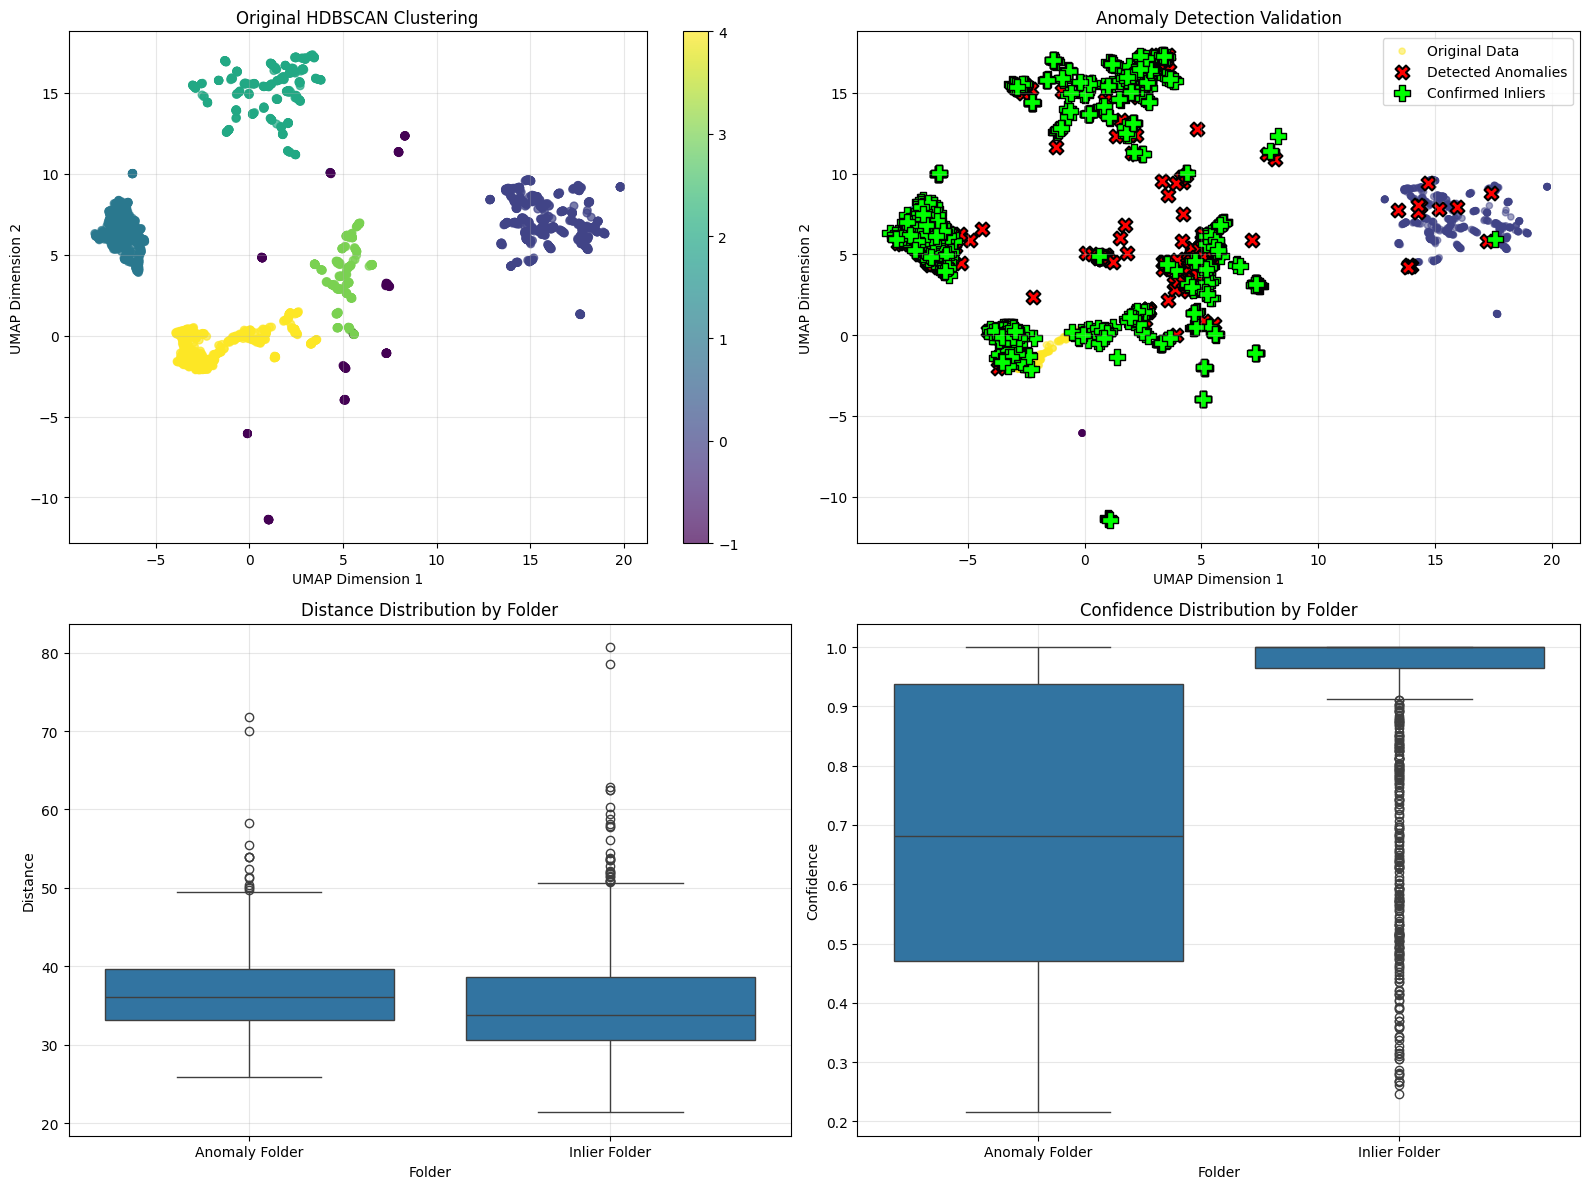


✅ Analysis complete! Results saved to CSV files.


In [4]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap
import hdbscan
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
import pandas as pd
from scipy import stats
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

class AnomalyDetectionSystem:
    """Enhanced anomaly detection system with multiple detection methods and comprehensive evaluation."""
    
    def __init__(self, custom_model_path: str, use_standard_scaler: bool = True):
        """Initialize the anomaly detection system."""
        self.mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
        self.custom_model = load_model(custom_model_path)
        self.custom_feature_model = Model(inputs=self.custom_model.input, 
                                        outputs=self.custom_model.layers[-2].output)
        
        self.use_standard_scaler = use_standard_scaler
        self.scaler = StandardScaler() if use_standard_scaler else None
        self.umap_model = None
        self.cluster_centers = {}
        self.cluster_stats = {}
        
    def extract_features(self, img_path: str) -> np.ndarray:
        """Extract combined features from both models."""
        try:
            img = image.load_img(img_path, target_size=(224, 224))
            x = image.img_to_array(img)
            x = preprocess_input(x)
            x = np.expand_dims(x, axis=0)

            feat1 = self.mobilenet_model.predict(x, verbose=0)[0]
            feat2 = self.custom_feature_model.predict(x, verbose=0)[0]
            combined_features = np.concatenate([feat1, feat2])
            
            return combined_features
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            return None
    
    def extract_features_batch(self, image_folder: str) -> Tuple[np.ndarray, List[str]]:
        """Extract features from all images in a folder."""
        print(f"Extracting features from {image_folder}...")
        features = []
        filenames = []
        
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        
        for fname in os.listdir(image_folder):
            if fname.lower().endswith(valid_extensions):
                path = os.path.join(image_folder, fname)
                feat = self.extract_features(path)
                if feat is not None:
                    features.append(feat)
                    filenames.append(fname)
        
        features = np.array(features, dtype=np.float64)
        
        # Apply scaling if enabled
        if self.use_standard_scaler and len(features) > 0:
            features = self.scaler.fit_transform(features)
            
        print(f"✅ Extracted features for {len(filenames)} images.")
        return features, filenames
    
    def find_optimal_clusters(self, features: np.ndarray, max_k: int = 10) -> int:
        """Find optimal number of clusters using silhouette score."""
        if len(features) < 4:
            return 2
            
        silhouette_scores = []
        k_range = range(2, min(max_k + 1, len(features)))
        
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(features)
            score = silhouette_score(features, labels)
            silhouette_scores.append(score)
        
        optimal_k = k_range[np.argmax(silhouette_scores)]
        print(f"Optimal number of clusters: {optimal_k} (silhouette score: {max(silhouette_scores):.3f})")
        return optimal_k
    
    def fit_clustering_models(self, features: np.ndarray, filenames: List[str]) -> Dict:
        """Fit UMAP and HDBSCAN models and compute cluster statistics."""
        print("Running UMAP dimensionality reduction...")
        self.umap_model = umap.UMAP(
            n_neighbors=min(15, len(features) // 3),
            min_dist=0.1,
            n_components=2,
            metric='cosine',
            random_state=42
        )
        umap_embeddings = self.umap_model.fit_transform(features)
        
        print("Running HDBSCAN clustering...")
        # Adaptive min_cluster_size based on dataset size
        min_cluster_size = max(3, len(features) // 20)
        hdb = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=max(1, min_cluster_size // 2)
        )
        hdb_labels = hdb.fit_predict(umap_embeddings)
        
        # Compute cluster statistics
        self._compute_cluster_statistics(features, hdb_labels)
        
        return {
            'umap_embeddings': umap_embeddings,
            'hdb_labels': hdb_labels,
            'hdb_model': hdb
        }
    
    def _compute_cluster_statistics(self, features: np.ndarray, labels: np.ndarray):
        """Compute comprehensive cluster statistics."""
        unique_labels = np.unique(labels)
        inlier_features = features[labels != -1]
        inlier_labels = labels[labels != -1]
        
        for label in unique_labels:
            if label == -1:
                continue
                
            cluster_features = inlier_features[inlier_labels == label]
            center = cluster_features.mean(axis=0)
            
            # Compute various statistics
            distances_to_center = [np.linalg.norm(feat - center) for feat in cluster_features]
            
            self.cluster_centers[label] = center
            self.cluster_stats[label] = {
                'center': center,
                'size': len(cluster_features),
                'mean_distance': np.mean(distances_to_center),
                'std_distance': np.std(distances_to_center),
                'percentile_95': np.percentile(distances_to_center, 95),
                'percentile_99': np.percentile(distances_to_center, 99)
            }
        
        print(f"Computed statistics for {len(self.cluster_centers)} clusters.")
    
    def detect_anomalies_advanced(self, img_path: str, 
                                 distance_method: str = 'percentile',
                                 confidence_threshold: float = 0.7) -> Dict:
        """Advanced anomaly detection with multiple methods."""
        features = self.extract_features(img_path)
        if features is None:
            return {'error': 'Failed to extract features'}
        
        if self.use_standard_scaler and self.scaler:
            features = self.scaler.transform(features.reshape(1, -1))[0]
        
        # Get prediction confidence
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)
        prediction = self.custom_model.predict(x, verbose=0)[0]
        max_confidence = np.max(prediction)
        
        # Distance-based detection with multiple methods
        distances = {}
        anomaly_scores = {}
        
        for label, stats in self.cluster_stats.items():
            center = stats['center']
            distance = np.linalg.norm(features - center)
            distances[label] = distance
            
            if distance_method == 'adaptive':
                # Use cluster-specific thresholds based on statistics
                threshold = stats['mean_distance'] + 2 * stats['std_distance']
            elif distance_method == 'percentile':
                threshold = stats['percentile_95']
            else:  # fixed
                threshold = 40.0
            
            anomaly_scores[label] = distance > threshold
        
        min_distance = min(distances.values()) if distances else float('inf')
        closest_cluster = min(distances, key=distances.get) if distances else -1
        
        # Combined anomaly detection
        distance_anomaly = min(anomaly_scores.values()) if anomaly_scores else True
        confidence_anomaly = max_confidence < confidence_threshold
        
        # Multi-criteria decision
        is_anomaly = (
            distance_anomaly or 
            confidence_anomaly or 
            max_confidence < 0.2 or 
            min_distance > 60
        )
        
        return {
            'min_distance': min_distance,
            'closest_cluster': closest_cluster,
            'max_confidence': max_confidence,
            'distance_anomaly': distance_anomaly,
            'confidence_anomaly': confidence_anomaly,
            'is_anomaly': is_anomaly,
            'all_distances': distances,
            'anomaly_scores': anomaly_scores
        }
    
    def evaluate_folder(self, folder_path: str, 
                       distance_method: str = 'adaptive',
                       confidence_threshold: float = 0.7) -> List[Dict]:
        """Evaluate all images in a folder for anomalies."""
        print(f"\nEvaluating folder: {folder_path}")
        
        if not os.path.exists(folder_path):
            print(f"⚠️ ERROR: Folder not found.")
            return []
        
        results = []
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        
        for fname in os.listdir(folder_path):
            if fname.lower().endswith(valid_extensions):
                path = os.path.join(folder_path, fname)
                result = self.detect_anomalies_advanced(path, distance_method, confidence_threshold)
                if 'error' not in result:
                    result['filename'] = fname
                    results.append(result)
        
        print(f"✅ Evaluated {len(results)} images.")
        return results
    
    def generate_comprehensive_report(self, results: List[Dict], folder_name: str, 
                                    confidence_threshold: float) -> pd.DataFrame:
        """Generate comprehensive evaluation report."""
        if not results:
            print(f"No results for {folder_name}")
            return pd.DataFrame()
        
        df = pd.DataFrame(results)
        
        total_count = len(results)
        anomaly_count = df['is_anomaly'].sum()
        distance_anomaly_count = df['distance_anomaly'].sum()
        confidence_anomaly_count = df['confidence_anomaly'].sum()
        
        print(f"\n=== COMPREHENSIVE REPORT: {folder_name} ===")
        print(f"Total Images: {total_count}")
        print(f"Confidence Threshold: {confidence_threshold}")
        print(f"{'='*50}")
        print(f"Total Anomalies: {anomaly_count} ({anomaly_count/total_count*100:.1f}%)")
        print(f"Distance-based Anomalies: {distance_anomaly_count} ({distance_anomaly_count/total_count*100:.1f}%)")
        print(f"Confidence-based Anomalies: {confidence_anomaly_count} ({confidence_anomaly_count/total_count*100:.1f}%)")
        print(f"{'='*50}")
        
        # Statistical summary
        print(f"Distance Statistics:")
        print(f"  Mean: {df['min_distance'].mean():.2f}")
        print(f"  Std: {df['min_distance'].std():.2f}")
        print(f"  95th percentile: {df['min_distance'].quantile(0.95):.2f}")
        
        print(f"Confidence Statistics:")
        print(f"  Mean: {df['max_confidence'].mean():.3f}")
        print(f"  Std: {df['max_confidence'].std():.3f}")
        print(f"  5th percentile: {df['max_confidence'].quantile(0.05):.3f}")
        
        return df
    
    def visualize_results(self, original_embeddings: np.ndarray, original_labels: np.ndarray,
                         anomaly_results: List[Dict] = None, inlier_results: List[Dict] = None,
                         anomaly_folder: str = None, inlier_folder: str = None):
        """Create comprehensive visualization of results."""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Original clustering
        scatter1 = ax1.scatter(original_embeddings[:, 0], original_embeddings[:, 1], 
                              c=original_labels, cmap='viridis', s=30, alpha=0.7)
        ax1.set_title("Original HDBSCAN Clustering")
        ax1.set_xlabel("UMAP Dimension 1")
        ax1.set_ylabel("UMAP Dimension 2")
        ax1.grid(True, alpha=0.3)
        plt.colorbar(scatter1, ax=ax1)
        
        # Plot 2: Anomaly validation with new data
        ax2.scatter(original_embeddings[:, 0], original_embeddings[:, 1], 
                   c=original_labels, cmap='viridis', s=20, alpha=0.5, label='Original Data')
        
        if anomaly_results and anomaly_folder:
            anomaly_features = []
            for result in anomaly_results:
                if not result['is_anomaly']:
                    continue
                path = os.path.join(anomaly_folder, result['filename'])
                feat = self.extract_features(path)
                if feat is not None:
                    if self.use_standard_scaler and self.scaler:
                        feat = self.scaler.transform(feat.reshape(1, -1))[0]
                    anomaly_features.append(feat)
            
            if anomaly_features:
                anomaly_embeddings = self.umap_model.transform(np.array(anomaly_features))
                ax2.scatter(anomaly_embeddings[:, 0], anomaly_embeddings[:, 1], 
                           c='red', marker='X', s=100, label='Detected Anomalies', 
                           edgecolors='black', linewidth=1.5)
        
        if inlier_results and inlier_folder:
            inlier_features = []
            for result in inlier_results:
                if result['is_anomaly']:
                    continue
                path = os.path.join(inlier_folder, result['filename'])
                feat = self.extract_features(path)
                if feat is not None:
                    if self.use_standard_scaler and self.scaler:
                        feat = self.scaler.transform(feat.reshape(1, -1))[0]
                    inlier_features.append(feat)
            
            if inlier_features:
                inlier_embeddings = self.umap_model.transform(np.array(inlier_features))
                ax2.scatter(inlier_embeddings[:, 0], inlier_embeddings[:, 1], 
                           c='lime', marker='P', s=120, label='Confirmed Inliers', 
                           edgecolors='black', linewidth=1)
        
        ax2.set_title("Anomaly Detection Validation")
        ax2.set_xlabel("UMAP Dimension 1")
        ax2.set_ylabel("UMAP Dimension 2")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Distance distribution
        if anomaly_results or inlier_results:
            all_distances = []
            labels = []
            
            if anomaly_results:
                all_distances.extend([r['min_distance'] for r in anomaly_results])
                labels.extend(['Anomaly Folder'] * len(anomaly_results))
            
            if inlier_results:
                all_distances.extend([r['min_distance'] for r in inlier_results])
                labels.extend(['Inlier Folder'] * len(inlier_results))
            
            if all_distances:
                df_dist = pd.DataFrame({'Distance': all_distances, 'Folder': labels})
                sns.boxplot(data=df_dist, x='Folder', y='Distance', ax=ax3)
                ax3.set_title("Distance Distribution by Folder")
                ax3.grid(True, alpha=0.3)
        
        # Plot 4: Confidence distribution
        if anomaly_results or inlier_results:
            all_confidences = []
            labels = []
            
            if anomaly_results:
                all_confidences.extend([r['max_confidence'] for r in anomaly_results])
                labels.extend(['Anomaly Folder'] * len(anomaly_results))
            
            if inlier_results:
                all_confidences.extend([r['max_confidence'] for r in inlier_results])
                labels.extend(['Inlier Folder'] * len(inlier_results))
            
            if all_confidences:
                df_conf = pd.DataFrame({'Confidence': all_confidences, 'Folder': labels})
                sns.boxplot(data=df_conf, x='Folder', y='Confidence', ax=ax4)
                ax4.set_title("Confidence Distribution by Folder")
                ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# === Usage Example ===
if __name__ == "__main__":
    # Configuration
    image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
    custom_model_path = r"four_skin_disease_detection.h5"
    potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2"
    known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\known_disease"
    
    # Initialize system
    ads = AnomalyDetectionSystem(custom_model_path, use_standard_scaler=True)
    
    # Extract features and fit models
    features, filenames = ads.extract_features_batch(image_folder)
    
    if len(features) > 0:
        # Fit clustering models
        clustering_results = ads.fit_clustering_models(features, filenames)
        
        # Evaluate folders
        anomaly_results = ads.evaluate_folder(potential_anomaly_folder, 
                                            distance_method='fixed', 
                                            confidence_threshold=0.7)
        
        inlier_results = ads.evaluate_folder(known_inlier_folder, 
                                           distance_method='fixed', 
                                           confidence_threshold=0.7)
        
        # Generate reports
        anomaly_df = ads.generate_comprehensive_report(anomaly_results, "Potential Anomaly Folder", 0.7)
        inlier_df = ads.generate_comprehensive_report(inlier_results, "Known Inlier Folder", 0.7)
        
        # Visualize results
        ads.visualize_results(
            clustering_results['umap_embeddings'],
            clustering_results['hdb_labels'],
            anomaly_results,
            inlier_results,
            potential_anomaly_folder,
            known_inlier_folder
        )
        
        # Save detailed results to CSV
        if not anomaly_df.empty:
            anomaly_df.to_csv('anomaly_results.csv', index=False)
        if not inlier_df.empty:
            inlier_df.to_csv('inlier_results.csv', index=False)
        
        print("\n✅ Analysis complete! Results saved to CSV files.")
    else:
        print("No features extracted. Please check your image folder path.")

Extracting features from C:\Users\User\Downloads\Skin-disease-dataset\mixed-small...
✅ Extracted features for 2965 images.
Running UMAP dimensionality reduction...
Running HDBSCAN clustering...
Computed statistics for 5 clusters.
✅ Saved cluster data to cluster_data.json
   - 5 clusters
   - Feature dimension: 1536
   - Scaler enabled: True

Evaluating folder: C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2
✅ Evaluated 630 images.

Evaluating folder: C:\Users\User\Downloads\Skin-disease-dataset\known_disease
✅ Evaluated 1069 images.

=== COMPREHENSIVE REPORT: Potential Anomaly Folder ===
Total Images: 630
Confidence Threshold: 0.7
Total Anomalies: 418 (66.3%)
Distance-based Anomalies: 145 (23.0%)
Confidence-based Anomalies: 323 (51.3%)
Distance Statistics:
  Mean: 36.70
  Std: 5.38
  95th percentile: 45.53
Confidence Statistics:
  Mean: 0.682
  Std: 0.250
  5th percentile: 0.290

=== COMPREHENSIVE REPORT: Known Inlier Folder ===
Total Images: 1069
Confidence Threshold: 0.7


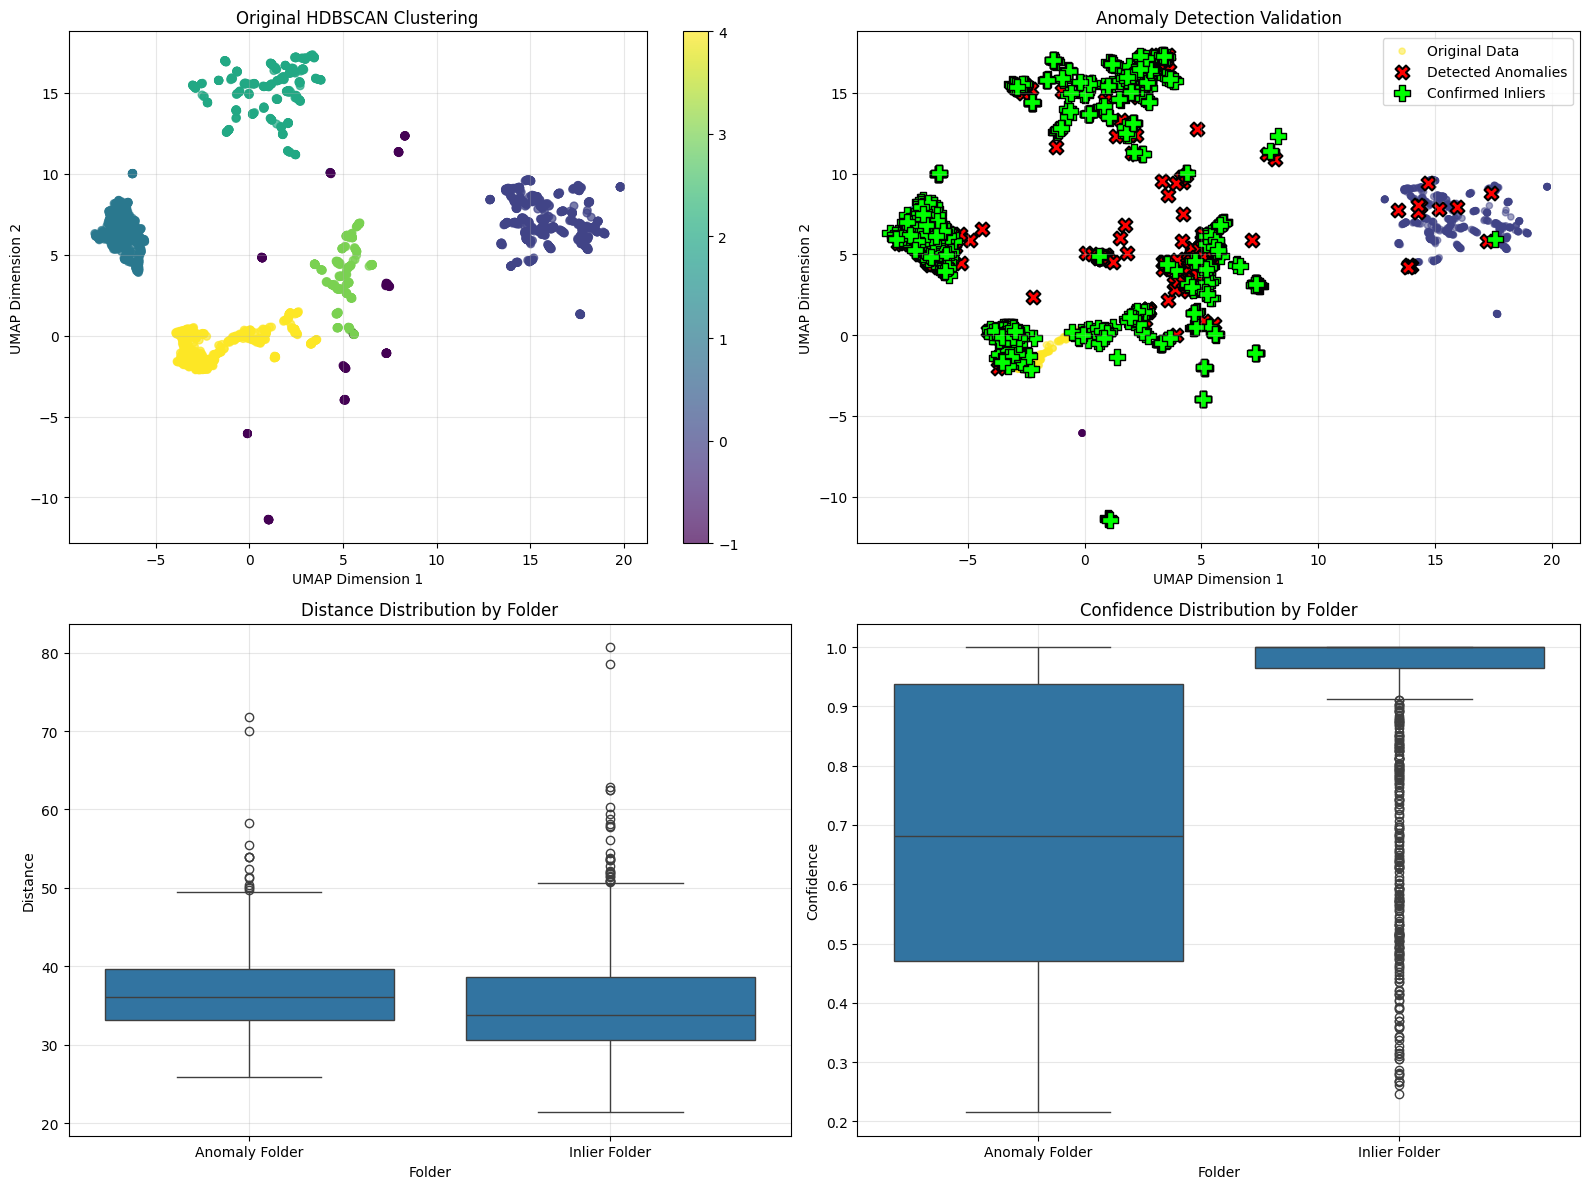


✅ Analysis complete! Results saved to CSV files.
✅ Cluster data saved for mobile deployment.


In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap
import hdbscan
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
import pandas as pd
from scipy import stats
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import json
import warnings
warnings.filterwarnings('ignore')

class AnomalyDetectionSystem:
    """Enhanced anomaly detection system with multiple detection methods and comprehensive evaluation."""
    
    def __init__(self, custom_model_path: str, use_standard_scaler: bool = True):
        """Initialize the anomaly detection system."""
        self.mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
        self.custom_model = load_model(custom_model_path)
        self.custom_feature_model = Model(inputs=self.custom_model.input, 
                                        outputs=self.custom_model.layers[-2].output)
        
        self.use_standard_scaler = use_standard_scaler
        self.scaler = StandardScaler() if use_standard_scaler else None
        self.umap_model = None
        self.cluster_centers = {}
        self.cluster_stats = {}
        self.scaler_params = {}  # Store scaler parameters for mobile use
        
    def extract_features(self, img_path: str) -> np.ndarray:
        """Extract combined features from both models."""
        try:
            img = image.load_img(img_path, target_size=(224, 224))
            x = image.img_to_array(img)
            x = preprocess_input(x)
            x = np.expand_dims(x, axis=0)

            feat1 = self.mobilenet_model.predict(x, verbose=0)[0]
            feat2 = self.custom_feature_model.predict(x, verbose=0)[0]
            combined_features = np.concatenate([feat1, feat2])
            
            return combined_features
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            return None
    
    def extract_features_batch(self, image_folder: str) -> Tuple[np.ndarray, List[str]]:
        """Extract features from all images in a folder."""
        print(f"Extracting features from {image_folder}...")
        features = []
        filenames = []
        
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        
        for fname in os.listdir(image_folder):
            if fname.lower().endswith(valid_extensions):
                path = os.path.join(image_folder, fname)
                feat = self.extract_features(path)
                if feat is not None:
                    features.append(feat)
                    filenames.append(fname)
        
        features = np.array(features, dtype=np.float64)
        
        # Apply scaling if enabled and store parameters
        if self.use_standard_scaler and len(features) > 0:
            features = self.scaler.fit_transform(features)
            # Store scaler parameters for mobile use
            self.scaler_params = {
                'mean': self.scaler.mean_.tolist(),
                'scale': self.scaler.scale_.tolist()
            }
            
        print(f"✅ Extracted features for {len(filenames)} images.")
        return features, filenames
    
    def find_optimal_clusters(self, features: np.ndarray, max_k: int = 10) -> int:
        """Find optimal number of clusters using silhouette score."""
        if len(features) < 4:
            return 2
            
        silhouette_scores = []
        k_range = range(2, min(max_k + 1, len(features)))
        
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(features)
            score = silhouette_score(features, labels)
            silhouette_scores.append(score)
        
        optimal_k = k_range[np.argmax(silhouette_scores)]
        print(f"Optimal number of clusters: {optimal_k} (silhouette score: {max(silhouette_scores):.3f})")
        return optimal_k
    
    def fit_clustering_models(self, features: np.ndarray, filenames: List[str]) -> Dict:
        """Fit UMAP and HDBSCAN models and compute cluster statistics."""
        print("Running UMAP dimensionality reduction...")
        self.umap_model = umap.UMAP(
            n_neighbors=min(15, len(features) // 3),
            min_dist=0.1,
            n_components=2,
            metric='cosine',
            random_state=42
        )
        umap_embeddings = self.umap_model.fit_transform(features)
        
        print("Running HDBSCAN clustering...")
        # Adaptive min_cluster_size based on dataset size
        min_cluster_size = max(3, len(features) // 20)
        hdb = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=max(1, min_cluster_size // 2)
        )
        hdb_labels = hdb.fit_predict(umap_embeddings)
        
        # Compute cluster statistics
        self._compute_cluster_statistics(features, hdb_labels)
        
        return {
            'umap_embeddings': umap_embeddings,
            'hdb_labels': hdb_labels,
            'hdb_model': hdb
        }
    
    def _compute_cluster_statistics(self, features: np.ndarray, labels: np.ndarray):
        """Compute comprehensive cluster statistics."""
        unique_labels = np.unique(labels)
        inlier_features = features[labels != -1]
        inlier_labels = labels[labels != -1]
        
        for label in unique_labels:
            if label == -1:
                continue
                
            cluster_features = inlier_features[inlier_labels == label]
            center = cluster_features.mean(axis=0)
            
            # Compute various statistics
            distances_to_center = [np.linalg.norm(feat - center) for feat in cluster_features]
            
            self.cluster_centers[label] = center
            self.cluster_stats[label] = {
                'center': center,
                'size': len(cluster_features),
                'mean_distance': np.mean(distances_to_center),
                'std_distance': np.std(distances_to_center),
                'percentile_95': np.percentile(distances_to_center, 95),
                'percentile_99': np.percentile(distances_to_center, 99)
            }
        
        print(f"Computed statistics for {len(self.cluster_centers)} clusters.")
    
    def save_cluster_centers(self, output_path: str):
        """Save cluster centers and statistics to a JSON file for mobile use."""
        export_data = {
            'cluster_centers': {
                str(k): v.tolist() for k, v in self.cluster_centers.items()
            },
            'cluster_stats': {
                str(k): {
                    'mean_distance': float(v['mean_distance']),
                    'std_distance': float(v['std_distance']),
                    'percentile_95': float(v['percentile_95']),
                    'percentile_99': float(v['percentile_99']),
                    'size': int(v['size'])
                } for k, v in self.cluster_stats.items()
            },
            'scaler_params': self.scaler_params,  # Include scaler parameters
            'metadata': {
                'total_clusters': len(self.cluster_centers),
                'use_standard_scaler': self.use_standard_scaler,
                'feature_dimension': len(next(iter(self.cluster_centers.values()))) if self.cluster_centers else 0
            }
        }
        
        with open(output_path, 'w') as f:
            json.dump(export_data, f, indent=2)
        print(f"✅ Saved cluster data to {output_path}")
        print(f"   - {len(self.cluster_centers)} clusters")
        print(f"   - Feature dimension: {export_data['metadata']['feature_dimension']}")
        print(f"   - Scaler enabled: {self.use_standard_scaler}")
    
    def detect_anomalies_advanced(self, img_path: str, 
                                 distance_method: str = 'percentile',
                                 confidence_threshold: float = 0.7) -> Dict:
        """Advanced anomaly detection with multiple methods."""
        features = self.extract_features(img_path)
        if features is None:
            return {'error': 'Failed to extract features'}
        
        if self.use_standard_scaler and self.scaler:
            features = self.scaler.transform(features.reshape(1, -1))[0]
        
        # Get prediction confidence
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)
        prediction = self.custom_model.predict(x, verbose=0)[0]
        max_confidence = np.max(prediction)
        
        # Distance-based detection with multiple methods
        distances = {}
        anomaly_scores = {}
        
        for label, stats in self.cluster_stats.items():
            center = stats['center']
            distance = np.linalg.norm(features - center)
            distances[label] = distance
            
            if distance_method == 'adaptive':
                # Use cluster-specific thresholds based on statistics
                threshold = stats['mean_distance'] + 2 * stats['std_distance']
            elif distance_method == 'percentile':
                threshold = stats['percentile_95']
            else:  # fixed
                threshold = 40.0
            
            anomaly_scores[label] = distance > threshold
        
        min_distance = min(distances.values()) if distances else float('inf')
        closest_cluster = min(distances, key=distances.get) if distances else -1
        
        # Combined anomaly detection
        distance_anomaly = min(anomaly_scores.values()) if anomaly_scores else True
        confidence_anomaly = max_confidence < confidence_threshold
        
        # Multi-criteria decision
        is_anomaly = (
            distance_anomaly or 
            confidence_anomaly or 
            max_confidence < 0.2 or 
            min_distance > 60
        )
        
        return {
            'min_distance': min_distance,
            'closest_cluster': closest_cluster,
            'max_confidence': max_confidence,
            'distance_anomaly': distance_anomaly,
            'confidence_anomaly': confidence_anomaly,
            'is_anomaly': is_anomaly,
            'all_distances': distances,
            'anomaly_scores': anomaly_scores
        }
    
    def evaluate_folder(self, folder_path: str, 
                       distance_method: str = 'adaptive',
                       confidence_threshold: float = 0.7) -> List[Dict]:
        """Evaluate all images in a folder for anomalies."""
        print(f"\nEvaluating folder: {folder_path}")
        
        if not os.path.exists(folder_path):
            print(f"⚠️ ERROR: Folder not found.")
            return []
        
        results = []
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        
        for fname in os.listdir(folder_path):
            if fname.lower().endswith(valid_extensions):
                path = os.path.join(folder_path, fname)
                result = self.detect_anomalies_advanced(path, distance_method, confidence_threshold)
                if 'error' not in result:
                    result['filename'] = fname
                    results.append(result)
        
        print(f"✅ Evaluated {len(results)} images.")
        return results
    
    def generate_comprehensive_report(self, results: List[Dict], folder_name: str, 
                                    confidence_threshold: float) -> pd.DataFrame:
        """Generate comprehensive evaluation report."""
        if not results:
            print(f"No results for {folder_name}")
            return pd.DataFrame()
        
        df = pd.DataFrame(results)
        
        total_count = len(results)
        anomaly_count = df['is_anomaly'].sum()
        distance_anomaly_count = df['distance_anomaly'].sum()
        confidence_anomaly_count = df['confidence_anomaly'].sum()
        
        print(f"\n=== COMPREHENSIVE REPORT: {folder_name} ===")
        print(f"Total Images: {total_count}")
        print(f"Confidence Threshold: {confidence_threshold}")
        print(f"{'='*50}")
        print(f"Total Anomalies: {anomaly_count} ({anomaly_count/total_count*100:.1f}%)")
        print(f"Distance-based Anomalies: {distance_anomaly_count} ({distance_anomaly_count/total_count*100:.1f}%)")
        print(f"Confidence-based Anomalies: {confidence_anomaly_count} ({confidence_anomaly_count/total_count*100:.1f}%)")
        print(f"{'='*50}")
        
        # Statistical summary
        print(f"Distance Statistics:")
        print(f"  Mean: {df['min_distance'].mean():.2f}")
        print(f"  Std: {df['min_distance'].std():.2f}")  
        print(f"  95th percentile: {df['min_distance'].quantile(0.95):.2f}")
        
        print(f"Confidence Statistics:")
        print(f"  Mean: {df['max_confidence'].mean():.3f}")
        print(f"  Std: {df['max_confidence'].std():.3f}")
        print(f"  5th percentile: {df['max_confidence'].quantile(0.05):.3f}")
        
        return df
    
    def visualize_results(self, original_embeddings: np.ndarray, original_labels: np.ndarray,
                         anomaly_results: List[Dict] = None, inlier_results: List[Dict] = None,
                         anomaly_folder: str = None, inlier_folder: str = None):
        """Create comprehensive visualization of results."""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Original clustering
        scatter1 = ax1.scatter(original_embeddings[:, 0], original_embeddings[:, 1], 
                              c=original_labels, cmap='viridis', s=30, alpha=0.7)
        ax1.set_title("Original HDBSCAN Clustering")
        ax1.set_xlabel("UMAP Dimension 1")
        ax1.set_ylabel("UMAP Dimension 2")
        ax1.grid(True, alpha=0.3)
        plt.colorbar(scatter1, ax=ax1)
        
        # Plot 2: Anomaly validation with new data
        ax2.scatter(original_embeddings[:, 0], original_embeddings[:, 1], 
                   c=original_labels, cmap='viridis', s=20, alpha=0.5, label='Original Data')
        
        if anomaly_results and anomaly_folder:
            anomaly_features = []
            for result in anomaly_results:
                if not result['is_anomaly']:
                    continue
                path = os.path.join(anomaly_folder, result['filename'])
                feat = self.extract_features(path)
                if feat is not None:
                    if self.use_standard_scaler and self.scaler:
                        feat = self.scaler.transform(feat.reshape(1, -1))[0]
                    anomaly_features.append(feat)
            
            if anomaly_features:
                anomaly_embeddings = self.umap_model.transform(np.array(anomaly_features))
                ax2.scatter(anomaly_embeddings[:, 0], anomaly_embeddings[:, 1], 
                           c='red', marker='X', s=100, label='Detected Anomalies', 
                           edgecolors='black', linewidth=1.5)
        
        if inlier_results and inlier_folder:
            inlier_features = []
            for result in inlier_results:
                if result['is_anomaly']:
                    continue
                path = os.path.join(inlier_folder, result['filename'])
                feat = self.extract_features(path)
                if feat is not None:
                    if self.use_standard_scaler and self.scaler:
                        feat = self.scaler.transform(feat.reshape(1, -1))[0]
                    inlier_features.append(feat)
            
            if inlier_features:
                inlier_embeddings = self.umap_model.transform(np.array(inlier_features))
                ax2.scatter(inlier_embeddings[:, 0], inlier_embeddings[:, 1], 
                           c='lime', marker='P', s=120, label='Confirmed Inliers', 
                           edgecolors='black', linewidth=1)
        
        ax2.set_title("Anomaly Detection Validation")
        ax2.set_xlabel("UMAP Dimension 1")
        ax2.set_ylabel("UMAP Dimension 2")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Distance distribution
        if anomaly_results or inlier_results:
            all_distances = []
            labels = []
            
            if anomaly_results:
                all_distances.extend([r['min_distance'] for r in anomaly_results])
                labels.extend(['Anomaly Folder'] * len(anomaly_results))
            
            if inlier_results:
                all_distances.extend([r['min_distance'] for r in inlier_results])
                labels.extend(['Inlier Folder'] * len(inlier_results))
            
            if all_distances:
                df_dist = pd.DataFrame({'Distance': all_distances, 'Folder': labels})
                sns.boxplot(data=df_dist, x='Folder', y='Distance', ax=ax3)
                ax3.set_title("Distance Distribution by Folder")
                ax3.grid(True, alpha=0.3)
        
        # Plot 4: Confidence distribution
        if anomaly_results or inlier_results:
            all_confidences = []
            labels = []
            
            if anomaly_results:
                all_confidences.extend([r['max_confidence'] for r in anomaly_results])
                labels.extend(['Anomaly Folder'] * len(anomaly_results))
            
            if inlier_results:
                all_confidences.extend([r['max_confidence'] for r in inlier_results])
                labels.extend(['Inlier Folder'] * len(inlier_results))
            
            if all_confidences:
                df_conf = pd.DataFrame({'Confidence': all_confidences, 'Folder': labels})
                sns.boxplot(data=df_conf, x='Folder', y='Confidence', ax=ax4)
                ax4.set_title("Confidence Distribution by Folder")
                ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# === Usage Example ===
if __name__ == "__main__":
    # Configuration
    image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
    custom_model_path = r"four_skin_disease_detection.h5"
    potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2"
    known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\known_disease"
    
    # Initialize system
    ads = AnomalyDetectionSystem(custom_model_path, use_standard_scaler=True)
    
    # Extract features and fit models
    features, filenames = ads.extract_features_batch(image_folder)
    
    if len(features) > 0:
        # Fit clustering models
        clustering_results = ads.fit_clustering_models(features, filenames)
        
        # Save cluster data for mobile use
        ads.save_cluster_centers('cluster_data.json')
        
        # Evaluate folders
        anomaly_results = ads.evaluate_folder(potential_anomaly_folder, 
                                            distance_method='fixed', 
                                            confidence_threshold=0.7)
        
        inlier_results = ads.evaluate_folder(known_inlier_folder, 
                                           distance_method='fixed', 
                                           confidence_threshold=0.7)
        
        # Generate reports
        anomaly_df = ads.generate_comprehensive_report(anomaly_results, "Potential Anomaly Folder", 0.7)
        inlier_df = ads.generate_comprehensive_report(inlier_results, "Known Inlier Folder", 0.7)
        
        # Visualize results
        ads.visualize_results(
            clustering_results['umap_embeddings'],
            clustering_results['hdb_labels'],
            anomaly_results,
            inlier_results,
            potential_anomaly_folder,
            known_inlier_folder
        )
        
        # Save detailed results to CSV
        if not anomaly_df.empty:
            anomaly_df.to_csv('anomaly_results.csv', index=False)
        if not inlier_df.empty:
            inlier_df.to_csv('inlier_results.csv', index=False)
        
        print("\n✅ Analysis complete! Results saved to CSV files.")
        print("✅ Cluster data saved for mobile deployment.")
    else:
        print("No features extracted. Please check your image folder path.")

Extracting features from C:\Users\User\Downloads\Skin-disease-dataset\mixed-small...
✅ Extracted features for 2965 images.
Running UMAP dimensionality reduction...
Running HDBSCAN clustering...
Computed statistics for 5 clusters.
✅ Saved cluster data to cluster_data.json
   - 5 clusters
   - Feature dimension: 256
   - Scaler enabled: True

Evaluating folder: C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2
✅ Evaluated 630 images.

Evaluating folder: C:\Users\User\Downloads\Skin-disease-dataset\known_disease
✅ Evaluated 1069 images.

=== COMPREHENSIVE REPORT: Potential Anomaly Folder ===
Total Images: 630
Confidence Threshold: 0.7
Total Anomalies: 214 (34.0%)
Distance-based Anomalies: 8 (1.3%)
Confidence-based Anomalies: 206 (32.7%)
Distance Statistics:
  Mean: 12.67
  Std: 9.28
  95th percentile: 20.01
Confidence Statistics:
  Mean: 0.785
  Std: 0.230
  5th percentile: 0.337

=== COMPREHENSIVE REPORT: Known Inlier Folder ===
Total Images: 1069
Confidence Threshold: 0.7
Tota

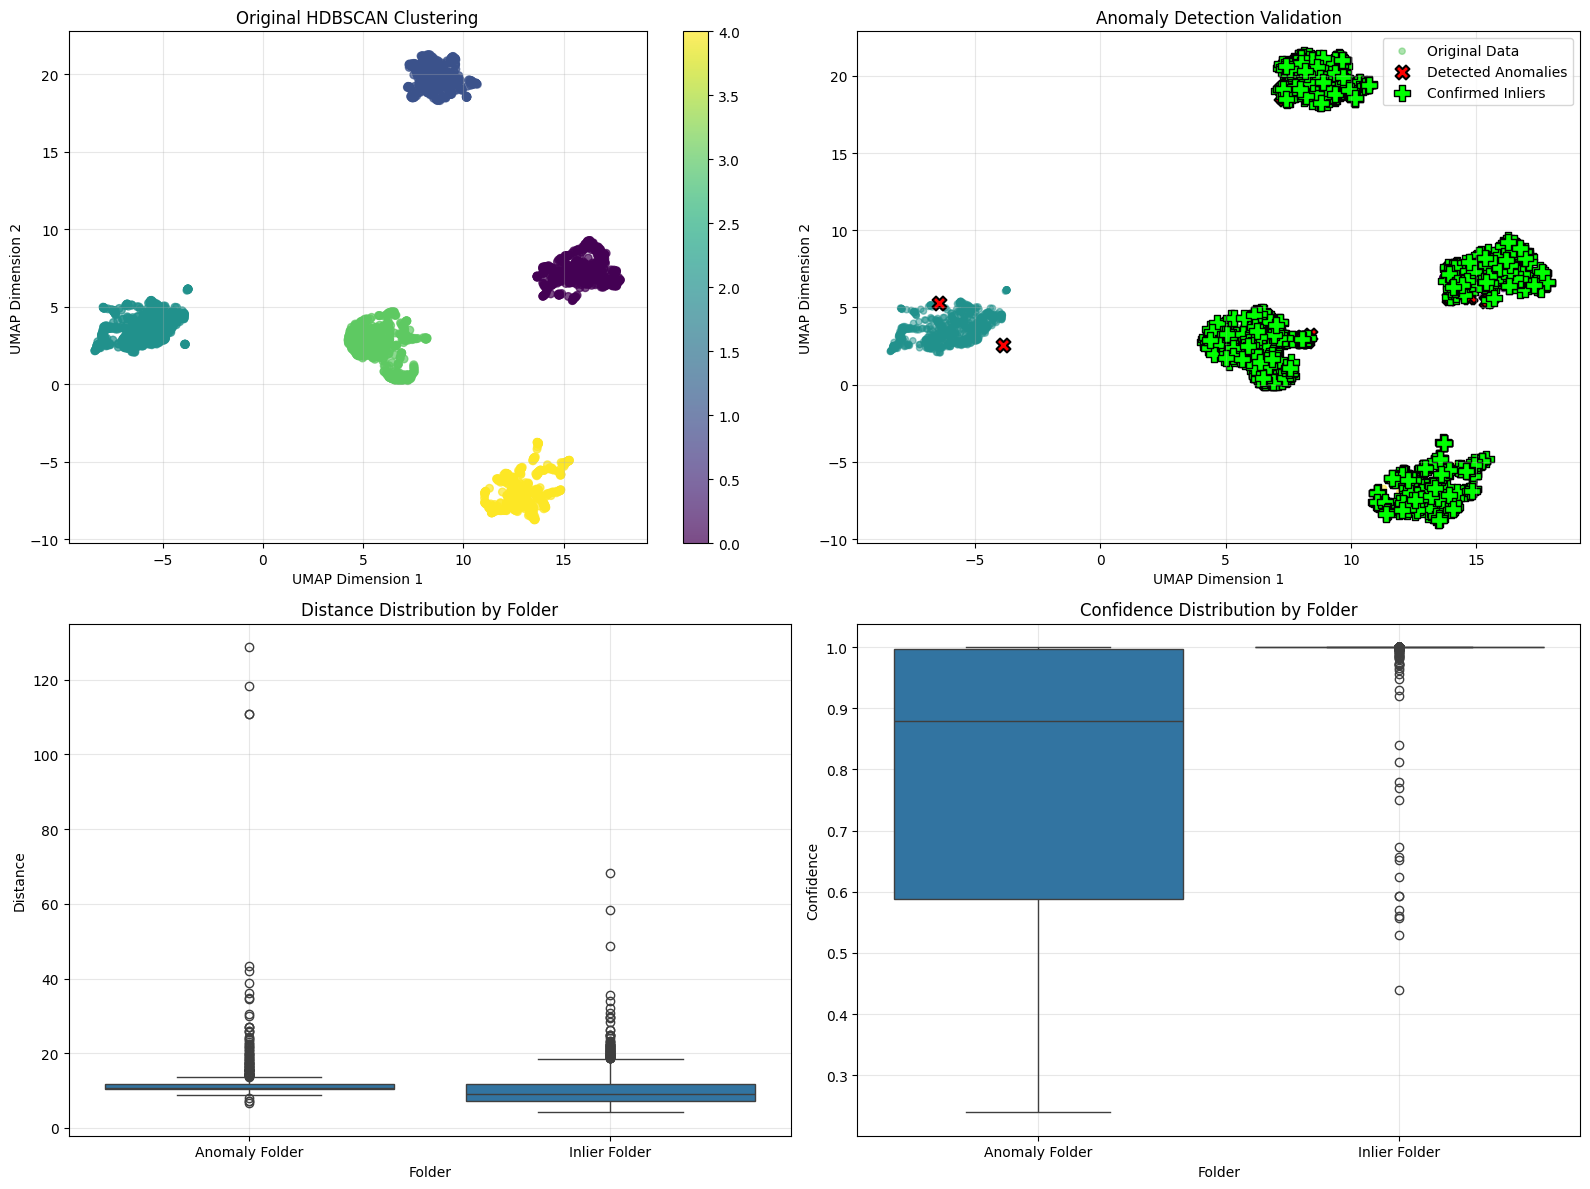


✅ Analysis complete! Results saved to CSV files.
✅ Cluster data saved for mobile deployment.


In [4]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap
import hdbscan
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
import pandas as pd
from scipy import stats
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import json
import warnings
warnings.filterwarnings('ignore')

class AnomalyDetectionSystem:
    """Enhanced anomaly detection system with custom model feature extraction and comprehensive evaluation."""
    
    def __init__(self, custom_model_path: str, use_standard_scaler: bool = True):
        """Initialize the anomaly detection system."""
        self.custom_model = load_model(custom_model_path)
        self.custom_feature_model = Model(inputs=self.custom_model.input, 
                                        outputs=self.custom_model.layers[-2].output)
        
        self.use_standard_scaler = use_standard_scaler
        self.scaler = StandardScaler() if use_standard_scaler else None
        self.umap_model = None
        self.cluster_centers = {}
        self.cluster_stats = {}
        self.scaler_params = {}  # Store scaler parameters for mobile use
        
    def extract_features(self, img_path: str) -> np.ndarray:
        """Extract features from custom model only."""
        try:
            img = image.load_img(img_path, target_size=(224, 224))
            x = image.img_to_array(img)
            x = x / 255.0  # Normalize to [0,1] range
            x = np.expand_dims(x, axis=0)

            features = self.custom_feature_model.predict(x, verbose=0)[0]
            
            return features
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            return None
    
    def extract_features_batch(self, image_folder: str) -> Tuple[np.ndarray, List[str]]:
        """Extract features from all images in a folder."""
        print(f"Extracting features from {image_folder}...")
        features = []
        filenames = []
        
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        
        for fname in os.listdir(image_folder):
            if fname.lower().endswith(valid_extensions):
                path = os.path.join(image_folder, fname)
                feat = self.extract_features(path)
                if feat is not None:
                    features.append(feat)
                    filenames.append(fname)
        
        features = np.array(features, dtype=np.float64)
        
        # Apply scaling if enabled and store parameters
        if self.use_standard_scaler and len(features) > 0:
            features = self.scaler.fit_transform(features)
            # Store scaler parameters for mobile use
            self.scaler_params = {
                'mean': self.scaler.mean_.tolist(),
                'scale': self.scaler.scale_.tolist()
            }
            
        print(f"✅ Extracted features for {len(filenames)} images.")
        return features, filenames
    
    def find_optimal_clusters(self, features: np.ndarray, max_k: int = 10) -> int:
        """Find optimal number of clusters using silhouette score."""
        if len(features) < 4:
            return 2
            
        silhouette_scores = []
        k_range = range(2, min(max_k + 1, len(features)))
        
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(features)
            score = silhouette_score(features, labels)
            silhouette_scores.append(score)
        
        optimal_k = k_range[np.argmax(silhouette_scores)]
        print(f"Optimal number of clusters: {optimal_k} (silhouette score: {max(silhouette_scores):.3f})")
        return optimal_k
    
    def fit_clustering_models(self, features: np.ndarray, filenames: List[str]) -> Dict:
        """Fit UMAP and HDBSCAN models and compute cluster statistics."""
        print("Running UMAP dimensionality reduction...")
        self.umap_model = umap.UMAP(
            n_neighbors=min(15, len(features) // 3),
            min_dist=0.1,
            n_components=2,
            metric='cosine',
            random_state=42
        )
        umap_embeddings = self.umap_model.fit_transform(features)
        
        print("Running HDBSCAN clustering...")
        # Adaptive min_cluster_size based on dataset size
        min_cluster_size = max(3, len(features) // 20)
        hdb = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=max(1, min_cluster_size // 2)
        )
        hdb_labels = hdb.fit_predict(umap_embeddings)
        
        # Compute cluster statistics
        self._compute_cluster_statistics(features, hdb_labels)
        
        return {
            'umap_embeddings': umap_embeddings,
            'hdb_labels': hdb_labels,
            'hdb_model': hdb
        }
    
    def _compute_cluster_statistics(self, features: np.ndarray, labels: np.ndarray):
        """Compute comprehensive cluster statistics."""
        unique_labels = np.unique(labels)
        inlier_features = features[labels != -1]
        inlier_labels = labels[labels != -1]
        
        for label in unique_labels:
            if label == -1:
                continue
                
            cluster_features = inlier_features[inlier_labels == label]
            center = cluster_features.mean(axis=0)
            
            # Compute various statistics
            distances_to_center = [np.linalg.norm(feat - center) for feat in cluster_features]
            
            self.cluster_centers[label] = center
            self.cluster_stats[label] = {
                'center': center,
                'size': len(cluster_features),
                'mean_distance': np.mean(distances_to_center),
                'std_distance': np.std(distances_to_center),
                'percentile_95': np.percentile(distances_to_center, 95),
                'percentile_99': np.percentile(distances_to_center, 99)
            }
        
        print(f"Computed statistics for {len(self.cluster_centers)} clusters.")
    
    def save_cluster_centers(self, output_path: str):
        """Save cluster centers and statistics to a JSON file for mobile use."""
        export_data = {
            'cluster_centers': {
                str(k): v.tolist() for k, v in self.cluster_centers.items()
            },
            'cluster_stats': {
                str(k): {
                    'mean_distance': float(v['mean_distance']),
                    'std_distance': float(v['std_distance']),
                    'percentile_95': float(v['percentile_95']),
                    'percentile_99': float(v['percentile_99']),
                    'size': int(v['size'])
                } for k, v in self.cluster_stats.items()
            },
            'scaler_params': self.scaler_params,  # Include scaler parameters
            'metadata': {
                'total_clusters': len(self.cluster_centers),
                'use_standard_scaler': self.use_standard_scaler,
                'feature_dimension': len(next(iter(self.cluster_centers.values()))) if self.cluster_centers else 0
            }
        }
        
        with open(output_path, 'w') as f:
            json.dump(export_data, f, indent=2)
        print(f"✅ Saved cluster data to {output_path}")
        print(f"   - {len(self.cluster_centers)} clusters")
        print(f"   - Feature dimension: {export_data['metadata']['feature_dimension']}")
        print(f"   - Scaler enabled: {self.use_standard_scaler}")
    
    def detect_anomalies_advanced(self, img_path: str, 
                                 distance_method: str = 'percentile',
                                 confidence_threshold: float = 0.7) -> Dict:
        """Advanced anomaly detection with multiple methods."""
        features = self.extract_features(img_path)
        if features is None:
            return {'error': 'Failed to extract features'}
        
        if self.use_standard_scaler and self.scaler:
            features = self.scaler.transform(features.reshape(1, -1))[0]
        
        # Get prediction confidence
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = x / 255.0  # Normalize to [0,1] range
        x = np.expand_dims(x, axis=0)
        prediction = self.custom_model.predict(x, verbose=0)[0]
        max_confidence = np.max(prediction)
        
        # Distance-based detection with multiple methods
        distances = {}
        anomaly_scores = {}
        
        for label, stats in self.cluster_stats.items():
            center = stats['center']
            distance = np.linalg.norm(features - center)
            distances[label] = distance
            
            if distance_method == 'adaptive':
                # Use cluster-specific thresholds based on statistics
                threshold = stats['mean_distance'] + 2 * stats['std_distance']
            elif distance_method == 'percentile':
                threshold = stats['percentile_95']
            else:  # fixed
                threshold = 35.0
            
            anomaly_scores[label] = distance > threshold
        
        min_distance = min(distances.values()) if distances else float('inf')
        closest_cluster = min(distances, key=distances.get) if distances else -1
        
        # Combined anomaly detection
        distance_anomaly = min(anomaly_scores.values()) if anomaly_scores else True
        confidence_anomaly = max_confidence < confidence_threshold
        
        # Multi-criteria decision
        is_anomaly = (
            distance_anomaly or 
            confidence_anomaly or 
            max_confidence < 0.2 or 
            min_distance > 60
        )
        
        return {
            'min_distance': min_distance,
            'closest_cluster': closest_cluster,
            'max_confidence': max_confidence,
            'distance_anomaly': distance_anomaly,
            'confidence_anomaly': confidence_anomaly,
            'is_anomaly': is_anomaly,
            'all_distances': distances,
            'anomaly_scores': anomaly_scores
        }
    
    def evaluate_folder(self, folder_path: str, 
                       distance_method: str = 'adaptive',
                       confidence_threshold: float = 0.7) -> List[Dict]:
        """Evaluate all images in a folder for anomalies."""
        print(f"\nEvaluating folder: {folder_path}")
        
        if not os.path.exists(folder_path):
            print(f"⚠️ ERROR: Folder not found.")
            return []
        
        results = []
        valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
        
        for fname in os.listdir(folder_path):
            if fname.lower().endswith(valid_extensions):
                path = os.path.join(folder_path, fname)
                result = self.detect_anomalies_advanced(path, distance_method, confidence_threshold)
                if 'error' not in result:
                    result['filename'] = fname
                    results.append(result)
        
        print(f"✅ Evaluated {len(results)} images.")
        return results
    
    def generate_comprehensive_report(self, results: List[Dict], folder_name: str, 
                                    confidence_threshold: float) -> pd.DataFrame:
        """Generate comprehensive evaluation report."""
        if not results:
            print(f"No results for {folder_name}")
            return pd.DataFrame()
        
        df = pd.DataFrame(results)
        
        total_count = len(results)
        anomaly_count = df['is_anomaly'].sum()
        distance_anomaly_count = df['distance_anomaly'].sum()
        confidence_anomaly_count = df['confidence_anomaly'].sum()
        
        print(f"\n=== COMPREHENSIVE REPORT: {folder_name} ===")
        print(f"Total Images: {total_count}")
        print(f"Confidence Threshold: {confidence_threshold}")
        print(f"{'='*50}")
        print(f"Total Anomalies: {anomaly_count} ({anomaly_count/total_count*100:.1f}%)")
        print(f"Distance-based Anomalies: {distance_anomaly_count} ({distance_anomaly_count/total_count*100:.1f}%)")
        print(f"Confidence-based Anomalies: {confidence_anomaly_count} ({confidence_anomaly_count/total_count*100:.1f}%)")
        print(f"{'='*50}")
        
        # Statistical summary
        print(f"Distance Statistics:")
        print(f"  Mean: {df['min_distance'].mean():.2f}")
        print(f"  Std: {df['min_distance'].std():.2f}")  
        print(f"  95th percentile: {df['min_distance'].quantile(0.95):.2f}")
        
        print(f"Confidence Statistics:")
        print(f"  Mean: {df['max_confidence'].mean():.3f}")
        print(f"  Std: {df['max_confidence'].std():.3f}")
        print(f"  5th percentile: {df['max_confidence'].quantile(0.05):.3f}")
        
        return df
    
    def visualize_results(self, original_embeddings: np.ndarray, original_labels: np.ndarray,
                         anomaly_results: List[Dict] = None, inlier_results: List[Dict] = None,
                         anomaly_folder: str = None, inlier_folder: str = None):
        """Create comprehensive visualization of results."""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Original clustering
        scatter1 = ax1.scatter(original_embeddings[:, 0], original_embeddings[:, 1], 
                              c=original_labels, cmap='viridis', s=30, alpha=0.7)
        ax1.set_title("Original HDBSCAN Clustering")
        ax1.set_xlabel("UMAP Dimension 1")
        ax1.set_ylabel("UMAP Dimension 2")
        ax1.grid(True, alpha=0.3)
        plt.colorbar(scatter1, ax=ax1)
        
        # Plot 2: Anomaly validation with new data
        ax2.scatter(original_embeddings[:, 0], original_embeddings[:, 1], 
                   c=original_labels, cmap='viridis', s=20, alpha=0.5, label='Original Data')
        
        if anomaly_results and anomaly_folder:
            anomaly_features = []
            for result in anomaly_results:
                if not result['is_anomaly']:
                    continue
                path = os.path.join(anomaly_folder, result['filename'])
                feat = self.extract_features(path)
                if feat is not None:
                    if self.use_standard_scaler and self.scaler:
                        feat = self.scaler.transform(feat.reshape(1, -1))[0]
                    anomaly_features.append(feat)
            
            if anomaly_features:
                anomaly_embeddings = self.umap_model.transform(np.array(anomaly_features))
                ax2.scatter(anomaly_embeddings[:, 0], anomaly_embeddings[:, 1], 
                           c='red', marker='X', s=100, label='Detected Anomalies', 
                           edgecolors='black', linewidth=1.5)
        
        if inlier_results and inlier_folder:
            inlier_features = []
            for result in inlier_results:
                if result['is_anomaly']:
                    continue
                path = os.path.join(inlier_folder, result['filename'])
                feat = self.extract_features(path)
                if feat is not None:
                    if self.use_standard_scaler and self.scaler:
                        feat = self.scaler.transform(feat.reshape(1, -1))[0]
                    inlier_features.append(feat)
            
            if inlier_features:
                inlier_embeddings = self.umap_model.transform(np.array(inlier_features))
                ax2.scatter(inlier_embeddings[:, 0], inlier_embeddings[:, 1], 
                           c='lime', marker='P', s=120, label='Confirmed Inliers', 
                           edgecolors='black', linewidth=1)
        
        ax2.set_title("Anomaly Detection Validation")
        ax2.set_xlabel("UMAP Dimension 1")
        ax2.set_ylabel("UMAP Dimension 2")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Distance distribution
        if anomaly_results or inlier_results:
            all_distances = []
            labels = []
            
            if anomaly_results:
                all_distances.extend([r['min_distance'] for r in anomaly_results])
                labels.extend(['Anomaly Folder'] * len(anomaly_results))
            
            if inlier_results:
                all_distances.extend([r['min_distance'] for r in inlier_results])
                labels.extend(['Inlier Folder'] * len(inlier_results))
            
            if all_distances:
                df_dist = pd.DataFrame({'Distance': all_distances, 'Folder': labels})
                sns.boxplot(data=df_dist, x='Folder', y='Distance', ax=ax3)
                ax3.set_title("Distance Distribution by Folder")
                ax3.grid(True, alpha=0.3)
        
        # Plot 4: Confidence distribution
        if anomaly_results or inlier_results:
            all_confidences = []
            labels = []
            
            if anomaly_results:
                all_confidences.extend([r['max_confidence'] for r in anomaly_results])
                labels.extend(['Anomaly Folder'] * len(anomaly_results))
            
            if inlier_results:
                all_confidences.extend([r['max_confidence'] for r in inlier_results])
                labels.extend(['Inlier Folder'] * len(inlier_results))
            
            if all_confidences:
                df_conf = pd.DataFrame({'Confidence': all_confidences, 'Folder': labels})
                sns.boxplot(data=df_conf, x='Folder', y='Confidence', ax=ax4)
                ax4.set_title("Confidence Distribution by Folder")
                ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# === Usage Example ===
if __name__ == "__main__":
    # Configuration
    image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
    custom_model_path = r"four_skin_disease_detection.h5"
    potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2"
    known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\known_disease"
    
    # Initialize system
    ads = AnomalyDetectionSystem(custom_model_path, use_standard_scaler=True)
    
    # Extract features and fit models
    features, filenames = ads.extract_features_batch(image_folder)
    
    if len(features) > 0:
        # Fit clustering models
        clustering_results = ads.fit_clustering_models(features, filenames)
        
        # Save cluster data for mobile use
        ads.save_cluster_centers('cluster_data.json')
        
        # Evaluate folders
        anomaly_results = ads.evaluate_folder(potential_anomaly_folder, 
                                            distance_method='fixed', 
                                            confidence_threshold=0.7)
        
        inlier_results = ads.evaluate_folder(known_inlier_folder, 
                                           distance_method='fixed', 
                                           confidence_threshold=0.7)
        
        # Generate reports
        anomaly_df = ads.generate_comprehensive_report(anomaly_results, "Potential Anomaly Folder", 0.7)
        inlier_df = ads.generate_comprehensive_report(inlier_results, "Known Inlier Folder", 0.7)
        
        # Visualize results
        ads.visualize_results(
            clustering_results['umap_embeddings'],
            clustering_results['hdb_labels'],
            anomaly_results,
            inlier_results,
            potential_anomaly_folder,
            known_inlier_folder
        )
        
        # Save detailed results to CSV
        if not anomaly_df.empty:
            anomaly_df.to_csv('anomaly_results.csv', index=False)
        if not inlier_df.empty:
            inlier_df.to_csv('inlier_results.csv', index=False)
        
        print("\n✅ Analysis complete! Results saved to CSV files.")
        print("✅ Cluster data saved for mobile deployment.")
    else:
        print("No features extracted. Please check your image folder path.")

Loading models...
Extracting features from images...
✅ Extracted combined features for 2965 images.
Running KMeans clustering (for visualization only)...


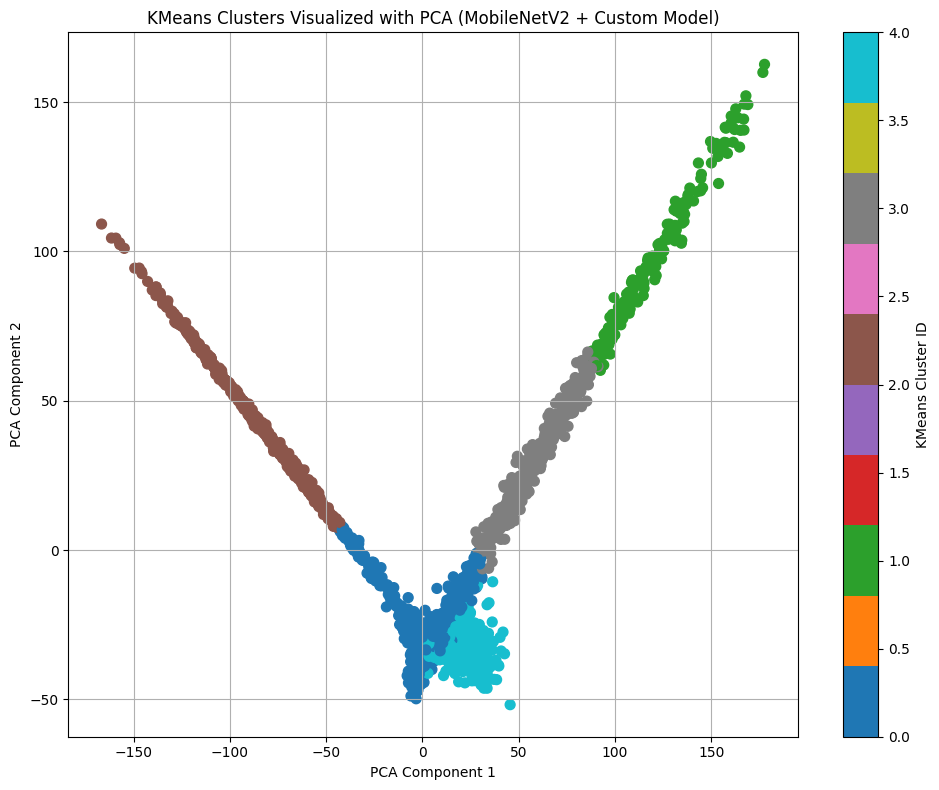

Running UMAP dimensionality reduction...


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running HDBSCAN clustering...


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


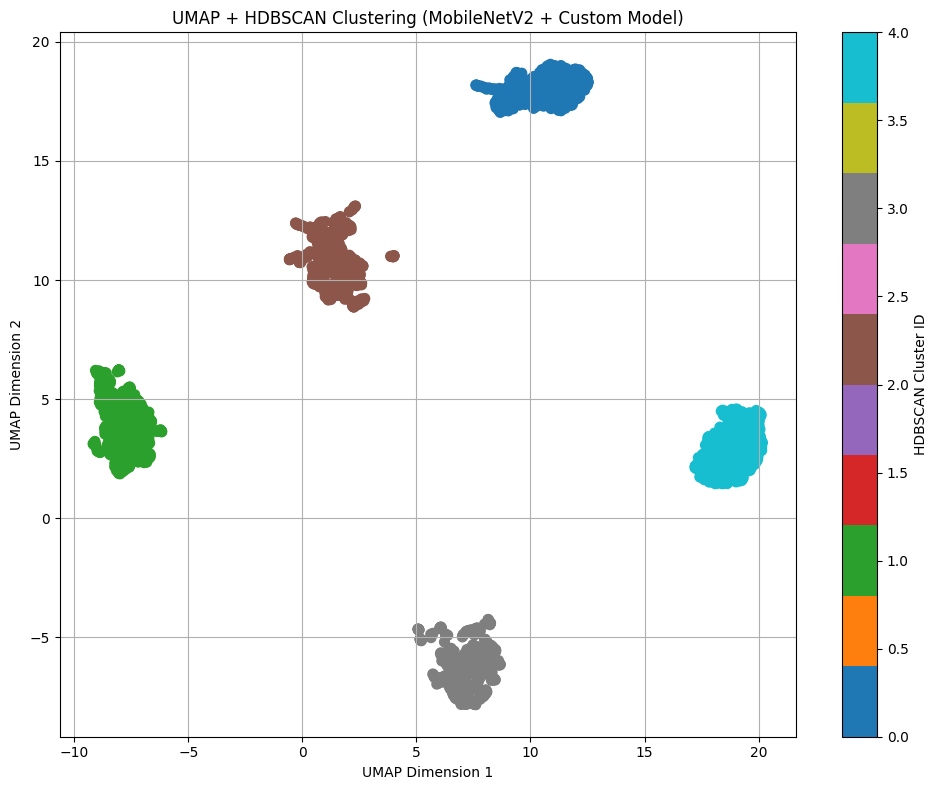

In [4]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import hdbscan
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image

# === Config ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
output_dir = "grouped_images_umap_hdbscan_combined"
k = 5  # KMeans clusters for visualization
custom_model_path = r"four_skin_disease_detection.h5"  # Change this to your .h5 model path

# === Step 1: Load Models ===
print("Loading models...")
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
custom_model = load_model(custom_model_path)

# Use second last layer as feature extractor
custom_feature_model = Model(inputs=custom_model.input, outputs=custom_model.layers[-2].output)

# === Step 2: Feature Extraction Function ===
def extract_features_both(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = preprocess_input(x)  # Assumes both models use MobileNetV2 preprocessing
    x = np.expand_dims(x, axis=0)

    feat1 = mobilenet_model.predict(x, verbose=0)[0]
    feat2 = custom_feature_model.predict(x, verbose=0)[0]
    
    return np.concatenate([feat1, feat2])  # Combine both feature vectors

# === Step 3: Extract Features ===
print("Extracting features from images...")
features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(image_folder, fname)
        feat = extract_features_both(path)
        features.append(feat)
        filenames.append(fname)

features = np.array(features, dtype=np.float64)
print(f"✅ Extracted combined features for {len(filenames)} images.")

# === Step 4: KMeans Clustering with PCA for Visualization ===
print("Running KMeans clustering (for visualization only)...")
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(features)

pca = PCA(n_components=2)
pca_features = pca.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=kmeans_labels, cmap='tab10', s=50)
plt.title("KMeans Clusters Visualized with PCA (MobileNetV2 + Custom Model)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="KMeans Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 5: UMAP Dimensionality Reduction ===
print("Running UMAP dimensionality reduction...")
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    low_memory=True,
    random_state=42
)
umap_embeddings = umap_model.fit_transform(features)

# === Step 6: HDBSCAN Clustering ===
print("Running HDBSCAN clustering...")
hdb = hdbscan.HDBSCAN(min_cluster_size=50)
hdb_labels = hdb.fit_predict(umap_embeddings)

# === Step 7: Save Grouped Images by Cluster ===
# print(f"Saving images grouped into folders at: {output_dir}...")
# os.makedirs(output_dir, exist_ok=True)

# for fname, cluster_id in zip(filenames, hdb_labels):
#     cluster_name = f"cluster_{cluster_id}" if cluster_id != -1 else "noise"
#     cluster_path = os.path.join(output_dir, cluster_name)
#     os.makedirs(cluster_path, exist_ok=True)
    
#     src = os.path.join(image_folder, fname)
#     dst = os.path.join(cluster_path, fname)
#     shutil.copy(src, dst)

# print("✅ Images grouped by HDBSCAN clusters saved.")

# === Step 8: UMAP + HDBSCAN Visualization ===
plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdb_labels, cmap='tab10', s=50)
plt.title("UMAP + HDBSCAN Clustering (MobileNetV2 + Custom Model)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="HDBSCAN Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()



--- Starting Anomaly & Inlier Validation ---
Calculating original cluster centers...
Computed centers for 5 clusters.

Processing folder: C:\Users\User\Downloads\Skin-disease-dataset\new_disease_2
✅ Processed 630 images.

Processing folder: C:\Users\User\Downloads\Skin-disease-dataset\known_disease
✅ Processed 555 images.

--- Validation Report for: Potential Anomaly Folder ---
Total Images: 630
Anomaly Threshold: 35.0
Anomalies Detected: 620 (98.41%)
--------------------------------------------------

--- Validation Report for: Known Inlier Folder ---
Total Images: 555
Anomaly Threshold: 35.0
Anomalies Detected: 427 (76.94%)
--------------------------------------------------

Generating combined visualization...


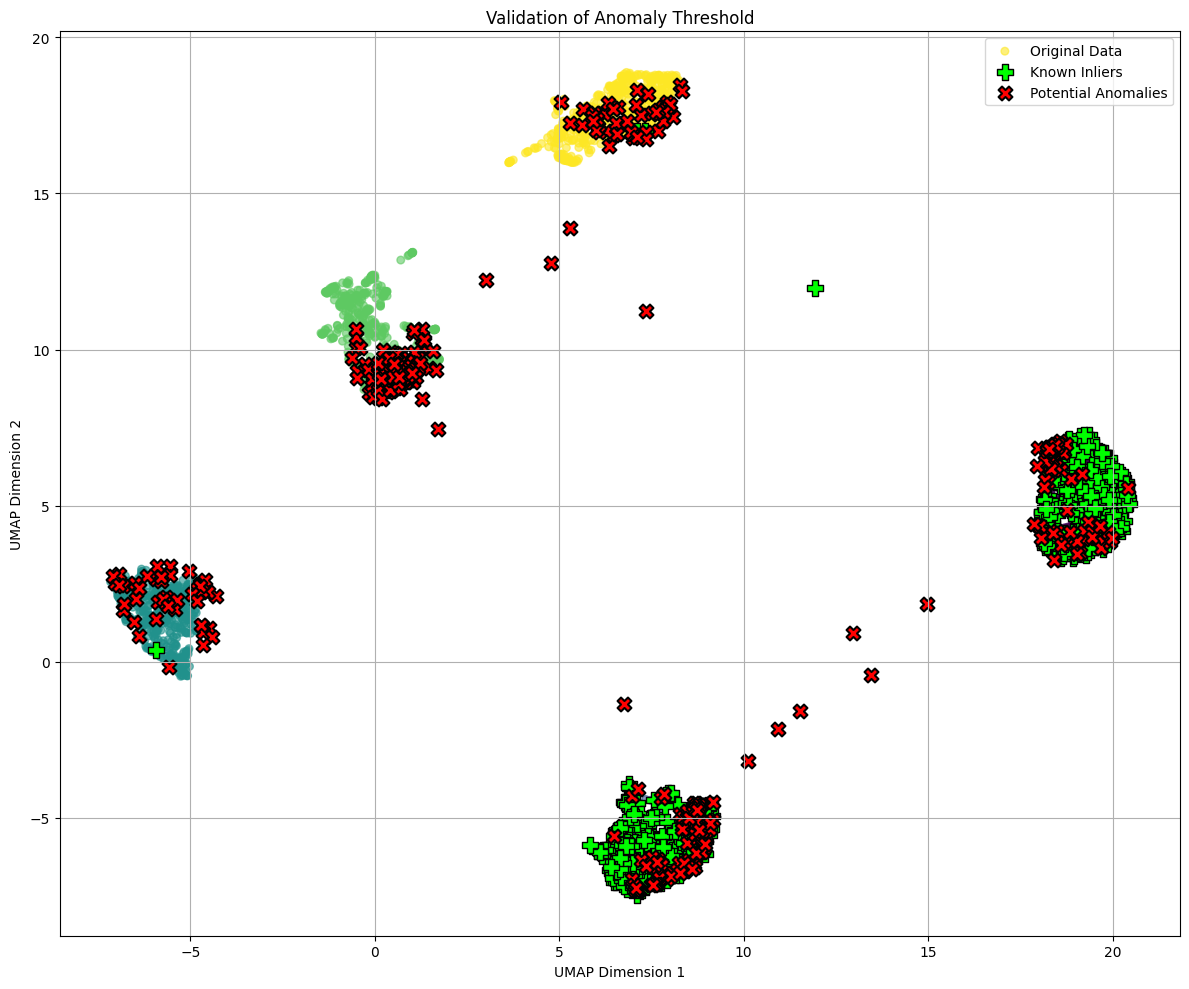

In [11]:
# === Step 9: Anomaly Detection Setup ===
print("\n--- Starting Anomaly & Inlier Validation ---")

# --- Configuration ---
# Folder with images you expect to be anomalies
potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease_2" 
# Folder with images you expect to be INLIERS (known diseases similar to original set)
known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\known_disease" # IMPORTANT: Change this path
# The distance threshold we are testing
anomaly_threshold = 35.0 
# --- End Configuration ---

print("Calculating original cluster centers...")
unique_labels = np.unique(hdb_labels)
cluster_centers = {}
original_inlier_features = features[hdb_labels != -1]
original_inlier_labels = hdb_labels[hdb_labels != -1]

for label in unique_labels:
    if label == -1:
        continue
    cluster_features = original_inlier_features[original_inlier_labels == label]
    center = cluster_features.mean(axis=0)
    cluster_centers[label] = center
print(f"Computed centers for {len(cluster_centers)} clusters.")


# === Step 10: Reusable Function to Process a Folder ===
def process_and_evaluate_folder(folder_path, cluster_centers, threshold):
    """Processes all images in a folder, checks for anomalies, and returns the results."""
    print(f"\nProcessing folder: {folder_path}")
    if not os.path.exists(folder_path):
        print(f"⚠️ ERROR: Folder not found. Skipping.")
        return [], []

    features_list, results_list = [], []
    for fname in os.listdir(folder_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder_path, fname)
            feat = extract_features_both(path)
            features_list.append(feat)

            distances = [np.linalg.norm(feat - center) for center in cluster_centers.values()]
            min_distance = min(distances) if distances else float('inf')
            
            results_list.append({
                "filename": fname,
                "min_distance": min_distance,
                "is_anomaly": min_distance > threshold
            })
    print(f"✅ Processed {len(features_list)} images.")
    return np.array(features_list, dtype=np.float64), results_list

def print_report(folder_name, results_list, threshold):
    """Prints a formatted report from the evaluation results."""
    if not results_list:
        return
        
    anomalies = [item for item in results_list if item["is_anomaly"]]
    total_count = len(results_list)
    anomaly_count = len(anomalies)
    anomaly_percentage = (anomaly_count / total_count) * 100 if total_count > 0 else 0

    print(f"\n--- Validation Report for: {folder_name} ---")
    print(f"Total Images: {total_count}")
    print(f"Anomaly Threshold: {threshold}")
    print(f"Anomalies Detected: {anomaly_count} ({anomaly_percentage:.2f}%)")
    print("--------------------------------------------------")


# === Step 11: Process Both Folders and Report ===
# Process the potential anomalies
anomaly_features, anomaly_results = process_and_evaluate_folder(
    potential_anomaly_folder, cluster_centers, anomaly_threshold
)
# Process the known inliers
inlier_features, inlier_results = process_and_evaluate_folder(
    known_inlier_folder, cluster_centers, anomaly_threshold
)

# Print the reports for both
print_report("Potential Anomaly Folder", anomaly_results, anomaly_threshold)
print_report("Known Inlier Folder", inlier_results, anomaly_threshold)


# === Step 12: Combined Visualization ===
print("\nGenerating combined visualization...")
# Use the FITTED umap_model to transform the new data
anomaly_embeddings = umap_model.transform(anomaly_features) if len(anomaly_features) > 0 else np.array([])
inlier_embeddings = umap_model.transform(inlier_features) if len(inlier_features) > 0 else np.array([])

plt.figure(figsize=(12, 10))

# 1. Plot the original data
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdb_labels, 
            cmap='viridis', s=30, alpha=0.6, label='Original Data')

# 2. Plot the new images from the "Known Inlier" folder (should be close to clusters)
if len(inlier_embeddings) > 0:
    plt.scatter(inlier_embeddings[:, 0], inlier_embeddings[:, 1], 
                c='lime', marker='P', s=120, label='Known Inliers', 
                edgecolors='black', linewidth=1)

# 3. Plot the new images from the "Anomaly" folder (should be far from clusters)
if len(anomaly_embeddings) > 0:
    plt.scatter(anomaly_embeddings[:, 0], anomaly_embeddings[:, 1], 
                c='red', marker='X', s=100, label='Potential Anomalies', 
                edgecolors='black', linewidth=1.5)

plt.title("Validation of Anomaly Threshold")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--- Starting Anomaly & Inlier Validation ---
Calculating original cluster centers...
Computed centers for 5 clusters.

Processing folder: C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\4
✅ Processed 432 images.

Processing folder: C:\Users\User\Downloads\Skin-disease-dataset\known_disease
✅ Processed 1069 images.

--- Validation Report for: Potential Anomaly Folder ---
Total Images: 432
Distance Threshold: 40.0
Confidence Threshold: 0.9
--------------------------------------------------
Total Anomalies: 274 (63.43%)
Distance-based Anomalies: 358 (82.87%)
Confidence-based Anomalies: 287 (66.44%)
--------------------------------------------------

--- Validation Report for: Known Inlier Folder ---
Total Images: 1069
Distance Threshold: 40.0
Confidence Threshold: 0.9
--------------------------------------------------
Total Anomalies: 388 (36.30%)
Distance-based Anomalies: 719 (67.26%)
Confidence-based Anomalies: 216 (20.21%)
--------------------------------------------------



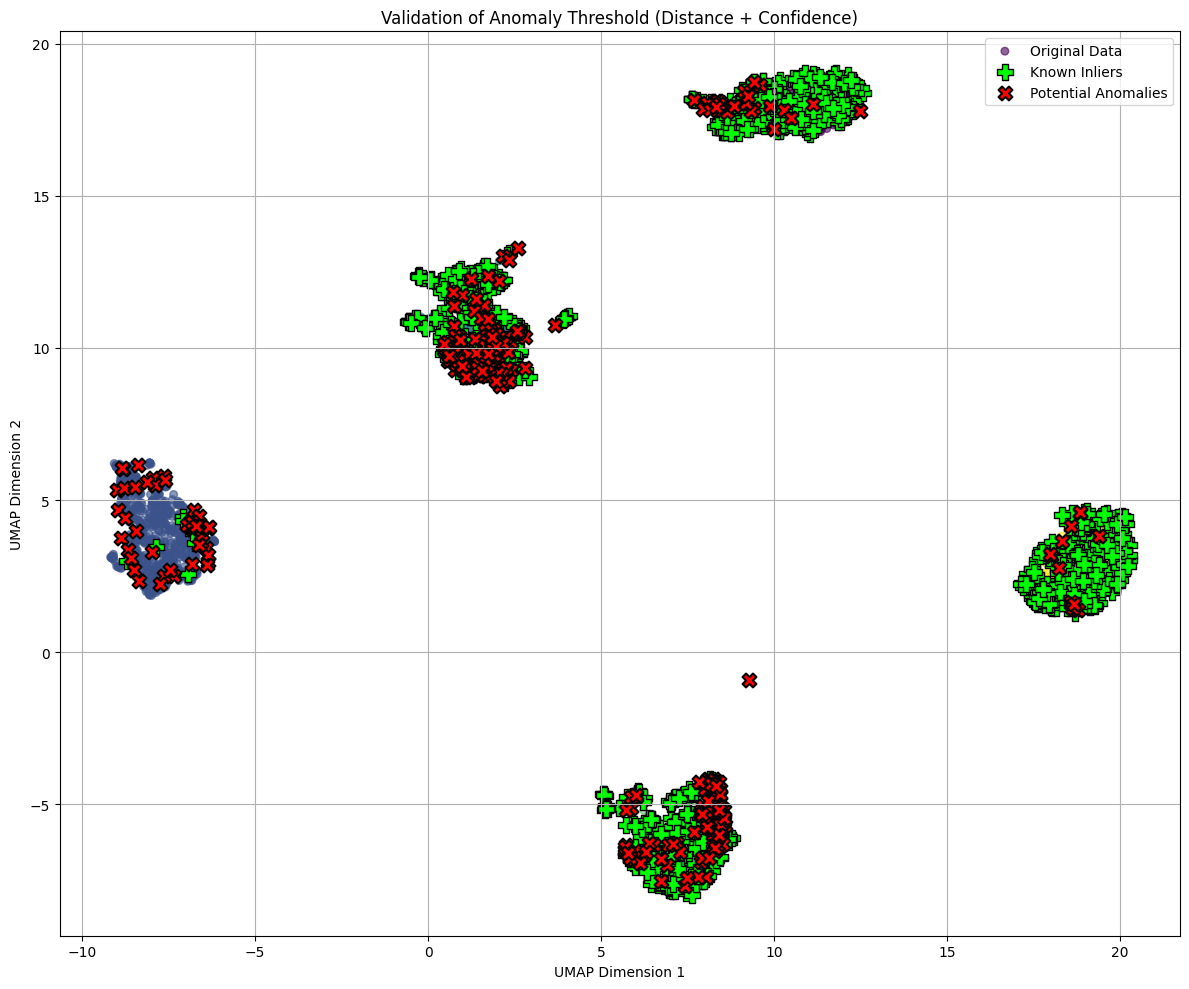

In [6]:
# === Step 9: Anomaly Detection Setup ===
print("\n--- Starting Anomaly & Inlier Validation ---")

# --- Configuration ---
# Folder with images you expect to be anomalies
potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\4" 
# Folder with images you expect to be INLIERS (known diseases similar to original set)
known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\known_disease" # IMPORTANT: Change this path
# The distance threshold we are testing
anomaly_threshold = 40.0 
# Confidence threshold for custom model predictions
confidence_threshold = 0.90
# --- End Configuration ---

print("Calculating original cluster centers...")
unique_labels = np.unique(hdb_labels)
cluster_centers = {}
original_inlier_features = features[hdb_labels != -1]
original_inlier_labels = hdb_labels[hdb_labels != -1]

for label in unique_labels:
    if label == -1:
        continue
    cluster_features = original_inlier_features[original_inlier_labels == label]
    center = cluster_features.mean(axis=0)
    cluster_centers[label] = center
print(f"Computed centers for {len(cluster_centers)} clusters.")


# === Step 10: Reusable Function to Process a Folder ===
def process_and_evaluate_folder(folder_path, cluster_centers, distance_threshold, confidence_threshold):
    """Processes all images in a folder, checks for anomalies using both distance and confidence, and returns the results."""
    print(f"\nProcessing folder: {folder_path}")
    if not os.path.exists(folder_path):
        print(f"⚠️ ERROR: Folder not found. Skipping.")
        return [], []

    features_list, results_list = [], []
    for fname in os.listdir(folder_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder_path, fname)
            feat = extract_features_both(path)
            features_list.append(feat)

            # Calculate distance-based anomaly detection
            distances = [np.linalg.norm(feat - center) for center in cluster_centers.values()]
            min_distance = min(distances) if distances else float('inf')
            distance_anomaly = min_distance > distance_threshold
            
            # Get prediction confidence from custom model
            img = image.load_img(path, target_size=(224, 224))
            x = image.img_to_array(img)
            x = preprocess_input(x)
            x = np.expand_dims(x, axis=0)
            
            prediction = custom_model.predict(x, verbose=0)[0]
            max_confidence = np.max(prediction)
            confidence_anomaly = max_confidence < confidence_threshold
            
            # Combined anomaly detection: anomaly if EITHER condition is met
            is_anomaly = (distance_anomaly and confidence_anomaly) or (max_confidence < .2) or  (min_distance > 60)
            
            results_list.append({
                "filename": fname,
                "min_distance": min_distance,
                "max_confidence": max_confidence,
                "distance_anomaly": distance_anomaly,
                "confidence_anomaly": confidence_anomaly,
                "is_anomaly": is_anomaly
            })
    print(f"✅ Processed {len(features_list)} images.")
    return np.array(features_list, dtype=np.float64), results_list

def print_report(folder_name, results_list, distance_threshold, confidence_threshold):
    """Prints a formatted report from the evaluation results."""
    if not results_list:
        return
        
    anomalies = [item for item in results_list if item["is_anomaly"]]
    distance_anomalies = [item for item in results_list if item["distance_anomaly"]]
    confidence_anomalies = [item for item in results_list if item["confidence_anomaly"]]
    
    total_count = len(results_list)
    anomaly_count = len(anomalies)
    distance_anomaly_count = len(distance_anomalies)
    confidence_anomaly_count = len(confidence_anomalies)
    
    anomaly_percentage = (anomaly_count / total_count) * 100 if total_count > 0 else 0
    distance_percentage = (distance_anomaly_count / total_count) * 100 if total_count > 0 else 0
    confidence_percentage = (confidence_anomaly_count / total_count) * 100 if total_count > 0 else 0

    print(f"\n--- Validation Report for: {folder_name} ---")
    print(f"Total Images: {total_count}")
    print(f"Distance Threshold: {distance_threshold}")
    print(f"Confidence Threshold: {confidence_threshold}")
    print(f"--------------------------------------------------")
    print(f"Total Anomalies: {anomaly_count} ({anomaly_percentage:.2f}%)")
    print(f"Distance-based Anomalies: {distance_anomaly_count} ({distance_percentage:.2f}%)")
    print(f"Confidence-based Anomalies: {confidence_anomaly_count} ({confidence_percentage:.2f}%)")
    print("--------------------------------------------------")


# === Step 11: Process Both Folders and Report ===
# Process the potential anomalies
anomaly_features, anomaly_results = process_and_evaluate_folder(
    potential_anomaly_folder, cluster_centers, anomaly_threshold, confidence_threshold
)
# Process the known inliers
inlier_features, inlier_results = process_and_evaluate_folder(
    known_inlier_folder, cluster_centers, anomaly_threshold, confidence_threshold
)

# Print the reports for both
print_report("Potential Anomaly Folder", anomaly_results, anomaly_threshold, confidence_threshold)
print_report("Known Inlier Folder", inlier_results, anomaly_threshold, confidence_threshold)


# === Step 12: Combined Visualization ===
print("\nGenerating combined visualization...")
# Use the FITTED umap_model to transform the new data
anomaly_embeddings = umap_model.transform(anomaly_features) if len(anomaly_features) > 0 else np.array([])
inlier_embeddings = umap_model.transform(inlier_features) if len(inlier_features) > 0 else np.array([])

plt.figure(figsize=(12, 10))

# 1. Plot the original data
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdb_labels, 
            cmap='viridis', s=30, alpha=0.6, label='Original Data')

# 2. Plot the new images from the "Known Inlier" folder (should be close to clusters)
if len(inlier_embeddings) > 0:
    plt.scatter(inlier_embeddings[:, 0], inlier_embeddings[:, 1], 
                c='lime', marker='P', s=120, label='Known Inliers', 
                edgecolors='black', linewidth=1)

# 3. Plot the new images from the "Anomaly" folder (should be far from clusters)
if len(anomaly_embeddings) > 0:
    plt.scatter(anomaly_embeddings[:, 0], anomaly_embeddings[:, 1], 
                c='red', marker='X', s=100, label='Potential Anomalies', 
                edgecolors='black', linewidth=1.5)

plt.title("Validation of Anomaly Threshold (Distance + Confidence)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 13: Optional - Print Detailed Results ===
def print_detailed_results(folder_name, results_list, max_items=10):
    """Print detailed results for first few items to inspect the dual criteria."""
    print(f"\n--- Detailed Results for {folder_name} (First {max_items} items) ---")
    for i, result in enumerate(results_list[:max_items]):
        print(f"{result['filename'][:30]:30} | Distance: {result['min_distance']:6.2f} | Confidence: {result['max_confidence']:6.3f} | "
              f"Dist_Anom: {result['distance_anomaly']} | Conf_Anom: {result['confidence_anomaly']} | Final: {result['is_anomaly']}")

# Uncomment these lines if you want to see detailed results
# print_detailed_results("Potential Anomaly Folder", anomaly_results)
# print_detailed_results("Known Inlier Folder", inlier_results) 1185 - 903

# Calculating centers averaging all images

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import hdbscan
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
import glob
from datetime import datetime
import gc  # For garbage collection
import tensorflow as tf

# === Config ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed"
output_dir = "grouped_images_umap_hdbscan_combined"
batch_size = 1000  # Process 1000 images at a time
target_clusters = 5  # Target number of clusters
max_batches = 25  # STOPPING POINT: Set how many batches to process (None for all)
custom_model_path = r"four_skin_disease_detection.h5"
results_csv_path = "clustering_results.csv"

# === Step 1: Load Models ===
print("Loading models...")
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
custom_model = load_model(custom_model_path)

# Use second last layer as feature extractor
custom_feature_model = Model(inputs=custom_model.input, outputs=custom_model.layers[-2].output)
print("✅ Models loaded successfully")

# === Step 2: Feature Extraction Function ===
def extract_features_both(img_path):
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)

        feat1 = mobilenet_model.predict(x, verbose=0)[0]
        feat2 = custom_feature_model.predict(x, verbose=0)[0]
        
        return np.concatenate([feat1, feat2])
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

# === Step 3: Get all image files ===
print("Scanning for image files...")
all_image_files = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    all_image_files.extend(glob.glob(os.path.join(image_folder, ext)))

total_images = len(all_image_files)
total_batches = (total_images + batch_size - 1) // batch_size  # Ceiling division

print(f"✅ Found {total_images} image files")
print(f"📊 Total possible batches: {total_batches}")

if max_batches is not None:
    batches_to_process = min(max_batches, total_batches)
    images_to_process = min(max_batches * batch_size, total_images)
    print(f"🛑 STOPPING POINT SET: Will process only {batches_to_process} batches ({images_to_process} images)")
else:
    batches_to_process = total_batches
    images_to_process = total_images
    print(f"🔄 Will process ALL {total_batches} batches ({total_images} images)")

# === Step 4: Memory management function ===
def clear_memory():
    """Clear memory after each batch"""
    gc.collect()  # Python garbage collection
    tf.keras.backend.clear_session()  # Clear TensorFlow session
    print("   🧹 Memory cleared")

# === Step 5: Initialize results storage ===
batch_results = []
all_cluster_centers = []  # To store centers from all batches
successful_batches = 0

# Create CSV with headers
df_columns = ['batch_number', 'batch_start_idx', 'batch_end_idx', 'images_processed', 
              'clusters_found', 'has_target_clusters', 'timestamp']
# Add columns for cluster centers (assuming combined feature dimension)
for i in range(target_clusters):
    df_columns.append(f'cluster_{i}_center_mean')

print(f"Starting batch processing: {batches_to_process} batches of {batch_size} images each")
print("="*60)

# === Step 6: Process images in batches ===
batches_processed = 0
for batch_idx in range(0, images_to_process, batch_size):
    if batches_processed >= batches_to_process:
        print(f"\n🛑 STOPPING: Reached maximum batch limit ({max_batches})")
        break
        
    batch_num = batches_processed + 1
    batch_end = min(batch_idx + batch_size, images_to_process)
    current_batch_files = all_image_files[batch_idx:batch_end]
    
    print(f"\n📦 Processing Batch {batch_num}/{batches_to_process}")
    print(f"   Images: {batch_idx + 1} to {batch_end} ({len(current_batch_files)} images)")
    
    # Extract features for current batch
    print("   🔍 Extracting features...")
    batch_features = []
    batch_filenames = []
    
    for i, img_path in enumerate(current_batch_files):
        if i % 100 == 0:  # Progress indicator
            print(f"      Processing image {i + 1}/{len(current_batch_files)}")
        
        feat = extract_features_both(img_path)
        if feat is not None:
            batch_features.append(feat)
            batch_filenames.append(os.path.basename(img_path))
    
    if len(batch_features) == 0:
        print("   ❌ No valid features extracted for this batch")
        clear_memory()  # Clear memory even for failed batches
        batches_processed += 1
        continue
    
    batch_features = np.array(batch_features, dtype=np.float64)
    print(f"   ✅ Extracted features for {len(batch_features)} images")
    
    # UMAP dimensionality reduction
    print("   🗺️  Running UMAP dimensionality reduction...")
    umap_model = umap.UMAP(
        n_neighbors=min(15, len(batch_features)-1),  # Adjust for small batches
        min_dist=0.1,
        n_components=2,
        metric='cosine',
        low_memory=True,
        random_state=42
    )
    umap_embeddings = umap_model.fit_transform(batch_features)
    print("   ✅ UMAP completed")
    
    # HDBSCAN clustering
    print("   🔗 Running HDBSCAN clustering...")
    min_cluster_size = max(10, len(batch_features) // 20)  # Adaptive cluster size
    hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
    hdb_labels = hdb.fit_predict(umap_embeddings)
    
    # Count clusters (excluding noise labeled as -1)
    unique_labels = np.unique(hdb_labels)
    clusters_found = len(unique_labels[unique_labels != -1])
    print(f"   ✅ HDBSCAN completed - Found {clusters_found} clusters")
    
    # Check if we have the target number of clusters
    has_target_clusters = (clusters_found == target_clusters)
    
    # Calculate cluster centers if we have the target number
    batch_cluster_centers = []
    if has_target_clusters:
        print(f"   🎯 Target clusters ({target_clusters}) found! Calculating centers...")
        valid_labels = unique_labels[unique_labels != -1]
        
        for label in sorted(valid_labels):
            cluster_mask = hdb_labels == label
            cluster_features = batch_features[cluster_mask]
            center = cluster_features.mean(axis=0)
            batch_cluster_centers.append(center)
            print(f"      Cluster {label}: {np.sum(cluster_mask)} images, center calculated")
        
        # Store centers for later averaging
        all_cluster_centers.append(batch_cluster_centers)
        successful_batches += 1
        print(f"   ✅ Cluster centers calculated and stored")
    else:
        print(f"   ⚠️  Only {clusters_found} clusters found (target: {target_clusters})")
    
    # Store batch results
    batch_result = {
        'batch_number': batch_num,
        'batch_start_idx': batch_idx + 1,
        'batch_end_idx': batch_end,
        'images_processed': len(batch_features),
        'clusters_found': clusters_found,
        'has_target_clusters': has_target_clusters,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    # Add cluster center means to results
    for i in range(target_clusters):
        if i < len(batch_cluster_centers):
            batch_result[f'cluster_{i}_center_mean'] = np.mean(batch_cluster_centers[i])
        else:
            batch_result[f'cluster_{i}_center_mean'] = np.nan
    
    batch_results.append(batch_result)
    
    print(f"   📊 Batch {batch_num} summary:")
    print(f"      - Images processed: {len(batch_features)}")
    print(f"      - Clusters found: {clusters_found}")
    print(f"      - Has target clusters: {has_target_clusters}")
    
    # === MEMORY CLEANUP ===
    print("   🗑️  Cleaning up memory...")
    # Delete large variables
    del batch_features, umap_embeddings, hdb_labels, umap_model, hdb
    if batch_cluster_centers:
        # Keep only what we need - cluster centers are already stored in all_cluster_centers
        pass
    del batch_cluster_centers
    
    # Clear memory
    clear_memory()
    
    batches_processed += 1
    print(f"   ✅ Batch {batch_num} completed and memory cleared")

print("\n" + "="*60)
print("🏁 BATCH PROCESSING COMPLETED")
print(f"   Total batches processed: {len(batch_results)}")
print(f"   Successful batches (with {target_clusters} clusters): {successful_batches}")

# === Step 7: Calculate overall average of cluster centers ===
if successful_batches > 0:
    print(f"\n📈 Calculating average cluster centers from {successful_batches} successful batches...")
    
    # Convert to numpy array for easier manipulation
    all_centers_array = np.array(all_cluster_centers)  # Shape: (successful_batches, target_clusters, feature_dim)
    
    # Calculate average center for each cluster across all successful batches
    average_cluster_centers = np.mean(all_centers_array, axis=0)  # Shape: (target_clusters, feature_dim)
    
    print("   ✅ Average cluster centers calculated")
    
    # Calculate overall average (average of all cluster centers)
    overall_average_center = np.mean(average_cluster_centers, axis=0)
    
    print(f"   📊 Cluster center statistics:")
    for i in range(target_clusters):
        center_mean = np.mean(average_cluster_centers[i])
        print(f"      Average Cluster {i} center mean: {center_mean:.6f}")
    
    overall_center_mean = np.mean(overall_average_center)
    print(f"   🎯 Overall average center mean: {overall_center_mean:.6f}")
    
    # Save average centers
    np.save('average_cluster_centers.npy', average_cluster_centers)
    np.save('overall_average_center.npy', overall_average_center)
    print("   💾 Average centers saved to .npy files")
    
    # Add overall statistics to results
    overall_stats = {
        'batch_number': 'OVERALL_STATS',
        'batch_start_idx': 1,
        'batch_end_idx': total_images,
        'images_processed': sum([r['images_processed'] for r in batch_results]),
        'clusters_found': f"Successful_batches: {successful_batches}",
        'has_target_clusters': True,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'overall_average_center_mean': overall_center_mean
    }
    
    # Add individual cluster averages
    for i in range(target_clusters):
        overall_stats[f'cluster_{i}_center_mean'] = np.mean(average_cluster_centers[i])
    
    batch_results.append(overall_stats)

else:
    print("\n❌ No successful batches found with target cluster count")

# === Step 8: Save results to CSV ===
print(f"\n💾 Saving results to {results_csv_path}...")
df = pd.DataFrame(batch_results)
df.to_csv(results_csv_path, index=False)
print("   ✅ Results saved to CSV")

# === Step 9: Print final summary ===
print("\n" + "="*60)
print("📋 FINAL SUMMARY")
print("="*60)
print(f"Total images found: {total_images}")
print(f"Images processed: {min(images_to_process, total_images)}")
print(f"Total batches processed: {batches_processed}")
print(f"Successful batches (with {target_clusters} clusters): {successful_batches}")
if batches_processed > 0:
    print(f"Success rate: {(successful_batches/batches_processed*100):.1f}%")

if successful_batches > 0:
    print(f"\n🎯 CLUSTER CENTER RESULTS:")
    print(f"Overall average center mean: {overall_center_mean:.6f}")
    for i in range(target_clusters):
        cluster_mean = np.mean(average_cluster_centers[i])
        print(f"Average Cluster {i} center mean: {cluster_mean:.6f}")

print(f"\n📁 FILES CREATED:")
print(f"- {results_csv_path}: Detailed batch results")
if successful_batches > 0:
    print(f"- average_cluster_centers.npy: Average centers for each cluster")
    print(f"- overall_average_center.npy: Overall average center")

print("\n✅ Process completed successfully!")

c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models...
✅ Models loaded successfully
Scanning for image files...
✅ Found 82192 image files
📊 Total possible batches: 83
🛑 STOPPING POINT SET: Will process only 25 batches (25000 images)
Starting batch processing: 25 batches of 1000 images each

📦 Processing Batch 1/25
   Images: 1 to 1000 (1000 images)
   🔍 Extracting features...
      Processing image 1/1000
      Processing image 101/1000
      Processing image 201/1000
      Processing image 301/1000
      Processing image 401/1000
      Processing image 501/1000
      Processing image 601/1000
      Processing image 701/1000
      Processing image 801/1000
      Processing image 901/1000
   ✅ Extracted features for 1000 images
   🗺️  Running UMAP dimensionality reduction...


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✅ UMAP completed
   🔗 Running HDBSCAN clustering...
   ✅ HDBSCAN completed - Found 3 clusters
   ⚠️  Only 3 clusters found (target: 5)
   📊 Batch 1 summary:
      - Images processed: 1000
      - Clusters found: 3
      - Has target clusters: False
   🗑️  Cleaning up memory...


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

   🧹 Memory cleared
   ✅ Batch 24 completed and memory cleared

📦 Processing Batch 25/25
   Images: 24001 to 25000 (1000 images)
   🔍 Extracting features...
      Processing image 1/1000
      Processing image 101/1000
      Processing image 201/1000
      Processing image 301/1000
      Processing image 401/1000
      Processing image 501/1000
      Processing image 601/1000
      Processing image 701/1000
      Processing image 801/1000
      Processing image 901/1000
   ✅ Extracted features for 1000 images
   🗺️  Running UMAP dimensionality reduction...


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✅ UMAP completed
   🔗 Running HDBSCAN clustering...
   ✅ HDBSCAN completed - Found 5 clusters
   🎯 Target clusters (5) found! Calculating centers...
      Cluster 0: 220 images, center calculated
      Cluster 1: 183 images, center calculated
      Cluster 2: 221 images, center calculated
      Cluster 3: 156 images, center calculated
      Cluster 4: 220 images, center calculated
   ✅ Cluster centers calculated and stored
   📊 Batch 25 summary:
      - Images processed: 1000
      - Clusters found: 5
      - Has target clusters: True
   🗑️  Cleaning up memory...


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


   🧹 Memory cleared
   ✅ Batch 25 completed and memory cleared

🏁 BATCH PROCESSING COMPLETED
   Total batches processed: 25
   Successful batches (with 5 clusters): 24

📈 Calculating average cluster centers from 24 successful batches...
   ✅ Average cluster centers calculated
   📊 Cluster center statistics:
      Average Cluster 0 center mean: 0.634081
      Average Cluster 1 center mean: 0.653850
      Average Cluster 2 center mean: 0.688920
      Average Cluster 3 center mean: 0.618436
      Average Cluster 4 center mean: 0.649635
   🎯 Overall average center mean: 0.648984
   💾 Average centers saved to .npy files

💾 Saving results to clustering_results.csv...
   ✅ Results saved to CSV

📋 FINAL SUMMARY
Total images found: 82192
Images processed: 25000
Total batches processed: 25
Successful batches (with 5 clusters): 24
Success rate: 96.0%

🎯 CLUSTER CENTER RESULTS:
Overall average center mean: 0.648984
Average Cluster 0 center mean: 0.634081
Average Cluster 1 center mean: 0.653850
Ave

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
import umap

# === Step 1: Configuration ===
print("=== Anomaly Detection Using Saved Cluster Centers ===")

# --- Configuration ---
# Folder with images you expect to be anomalies
potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2" 
# Folder with images you expect to be INLIERS (known diseases similar to original set)
known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small" # IMPORTANT: Change this path
# The distance threshold we are testing
anomaly_threshold = 35.0 
# Confidence threshold for custom model predictions
confidence_threshold = 0.90
# Paths to saved center files
saved_centers_path = "average_cluster_centers.npy"  # From previous batch processing
custom_model_path = r"four_skin_disease_detection.h5"
# --- End Configuration ---

# === Step 2: Load Models ===
print("Loading models...")
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
custom_model = load_model(custom_model_path)

# Use second last layer as feature extractor
custom_feature_model = Model(inputs=custom_model.input, outputs=custom_model.layers[-2].output)
print("✅ Models loaded successfully")

# === Step 3: Load Saved Cluster Centers ===
print("Loading saved cluster centers...")
try:
    average_cluster_centers = np.load(saved_centers_path)
    print(f"✅ Loaded cluster centers from {saved_centers_path}")
    print(f"   Shape: {average_cluster_centers.shape}")
    print(f"   Number of clusters: {len(average_cluster_centers)}")
    
    # Convert to dictionary format for compatibility with existing code
    cluster_centers = {}
    for i, center in enumerate(average_cluster_centers):
        cluster_centers[i] = center
    
    print(f"✅ Converted to dictionary format with {len(cluster_centers)} cluster centers")
    
except FileNotFoundError:
    print(f"❌ ERROR: Saved centers file not found at {saved_centers_path}")
    print("   Please run the batch clustering script first to generate the centers.")
    exit(1)
except Exception as e:
    print(f"❌ ERROR loading saved centers: {e}")
    exit(1)

# === Step 4: Feature Extraction Function ===
def extract_features_both(img_path):
    """Extract features using both MobileNetV2 and custom model"""
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(x)  # Assumes both models use MobileNetV2 preprocessing
        x = np.expand_dims(x, axis=0)

        feat1 = mobilenet_model.predict(x, verbose=0)[0]
        feat2 = custom_feature_model.predict(x, verbose=0)[0]
        
        return np.concatenate([feat1, feat2])  # Combine both feature vectors
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

print("✅ Feature extraction function ready")

# === Step 5: Reusable Function to Process a Folder ===
def process_and_evaluate_folder(folder_path, cluster_centers, distance_threshold, confidence_threshold):
    """Processes all images in a folder, checks for anomalies using both distance and confidence, and returns the results."""
    print(f"\nProcessing folder: {folder_path}")
    if not os.path.exists(folder_path):
        print(f"⚠️ ERROR: Folder not found. Skipping.")
        return [], []

    features_list, results_list = [], []
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    total_files = len(image_files)
    
    print(f"   Found {total_files} image files")
    
    for i, fname in enumerate(image_files):
        if i % 100 == 0:  # Progress indicator
            print(f"   Processing image {i + 1}/{total_files}")
            
        path = os.path.join(folder_path, fname)
        feat = extract_features_both(path)
        
        if feat is None:
            continue
            
        features_list.append(feat)

        # Calculate distance-based anomaly detection
        distances = [np.linalg.norm(feat - center) for center in cluster_centers.values()]
        min_distance = min(distances) if distances else float('inf')
        distance_anomaly = min_distance > distance_threshold
        
        # Get prediction confidence from custom model
        img = image.load_img(path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)
        
        prediction = custom_model.predict(x, verbose=0)[0]
        max_confidence = np.max(prediction)
        confidence_anomaly = max_confidence < confidence_threshold
        
        # Combined anomaly detection: anomaly if EITHER condition is met
        is_anomaly = (distance_anomaly and confidence_anomaly) or (max_confidence < 0.20) or (min_distance > 60)
        
        results_list.append({
            "filename": fname,
            "min_distance": min_distance,
            "max_confidence": max_confidence,
            "distance_anomaly": distance_anomaly,
            "confidence_anomaly": confidence_anomaly,
            "is_anomaly": is_anomaly
        })
    
    print(f"✅ Processed {len(features_list)} images successfully")
    return np.array(features_list, dtype=np.float64), results_list

# === Step 6: Report Function ===
def print_report(folder_name, results_list, distance_threshold, confidence_threshold):
    """Prints a formatted report from the evaluation results."""
    if not results_list:
        print(f"No results to report for {folder_name}")
        return
        
    anomalies = [item for item in results_list if item["is_anomaly"]]
    distance_anomalies = [item for item in results_list if item["distance_anomaly"]]
    confidence_anomalies = [item for item in results_list if item["confidence_anomaly"]]
    
    total_count = len(results_list)
    anomaly_count = len(anomalies)
    distance_anomaly_count = len(distance_anomalies)
    confidence_anomaly_count = len(confidence_anomalies)
    
    anomaly_percentage = (anomaly_count / total_count) * 100 if total_count > 0 else 0
    distance_percentage = (distance_anomaly_count / total_count) * 100 if total_count > 0 else 0
    confidence_percentage = (confidence_anomaly_count / total_count) * 100 if total_count > 0 else 0

    print(f"\n--- Validation Report for: {folder_name} ---")
    print(f"Total Images: {total_count}")
    print(f"Distance Threshold: {distance_threshold}")
    print(f"Confidence Threshold: {confidence_threshold}")
    print(f"--------------------------------------------------")
    print(f"Total Anomalies: {anomaly_count} ({anomaly_percentage:.2f}%)")
    print(f"Distance-based Anomalies: {distance_anomaly_count} ({distance_percentage:.2f}%)")
    print(f"Confidence-based Anomalies: {confidence_anomaly_count} ({confidence_percentage:.2f}%)")
    print("--------------------------------------------------")

# === Step 7: Process Both Folders and Report ===
print("\n" + "="*60)
print("STARTING ANOMALY DETECTION")
print("="*60)

# Process the potential anomalies
print("🔍 Processing potential anomaly folder...")
anomaly_features, anomaly_results = process_and_evaluate_folder(
    potential_anomaly_folder, cluster_centers, anomaly_threshold, confidence_threshold
)

# Process the known inliers
print("\n🔍 Processing known inlier folder...")
inlier_features, inlier_results = process_and_evaluate_folder(
    known_inlier_folder, cluster_centers, anomaly_threshold, confidence_threshold
)

# Print the reports for both
print("\n" + "="*60)
print("RESULTS")
print("="*60)
print_report("Potential Anomaly Folder", anomaly_results, anomaly_threshold, confidence_threshold)
print_report("Known Inlier Folder", inlier_results, anomaly_threshold, confidence_threshold)

# === Step 8: Visualization (Optional - if you want to visualize) ===
print("\n🎨 Generating visualization...")

# Note: For visualization, we'd need the original UMAP model from batch processing
# This is optional since we're focusing on anomaly detection results
try:
    # Create a simple 2D visualization using PCA as alternative to UMAP
    from sklearn.decomposition import PCA
    
    if len(anomaly_features) > 0 or len(inlier_features) > 0:
        # Combine all features for PCA
        all_new_features = []
        labels = []
        
        if len(anomaly_features) > 0:
            all_new_features.extend(anomaly_features)
            labels.extend(['Potential Anomaly'] * len(anomaly_features))
        
        if len(inlier_features) > 0:
            all_new_features.extend(inlier_features)
            labels.extend(['Known Inlier'] * len(inlier_features))
        
        if len(all_new_features) > 0:
            all_new_features = np.array(all_new_features)
            
            # Apply PCA for visualization
            pca = PCA(n_components=2)
            pca_features = pca.fit_transform(all_new_features)
            
            plt.figure(figsize=(10, 8))
            
            # Plot anomalies and inliers
            anomaly_mask = np.array(labels) == 'Potential Anomaly'
            inlier_mask = np.array(labels) == 'Known Inlier'
            
            if np.any(anomaly_mask):
                plt.scatter(pca_features[anomaly_mask, 0], pca_features[anomaly_mask, 1], 
                           c='red', marker='X', s=100, label='Potential Anomalies', 
                           edgecolors='black', linewidth=1.5)
            
            if np.any(inlier_mask):
                plt.scatter(pca_features[inlier_mask, 0], pca_features[inlier_mask, 1], 
                           c='lime', marker='P', s=120, label='Known Inliers', 
                           edgecolors='black', linewidth=1)
            
            plt.title("Anomaly Detection Results (PCA Visualization)")
            plt.xlabel("PCA Component 1")
            plt.ylabel("PCA Component 2")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            print("✅ Visualization completed")
        else:
            print("⚠️ No features to visualize")
    else:
        print("⚠️ No new data to visualize")
        
except Exception as e:
    print(f"⚠️ Visualization failed: {e}")

# === Step 9: Optional - Print Detailed Results ===
def print_detailed_results(folder_name, results_list, max_items=10):
    """Print detailed results for first few items to inspect the dual criteria."""
    if not results_list:
        return
        
    print(f"\n--- Detailed Results for {folder_name} (First {max_items} items) ---")
    print(f"{'Filename':<30} | {'Distance':<8} | {'Confidence':<10} | {'Dist_Anom':<9} | {'Conf_Anom':<9} | {'Final':<5}")
    print("-" * 80)
    
    for i, result in enumerate(results_list[:max_items]):
        print(f"{result['filename'][:30]:<30} | {result['min_distance']:8.2f} | {result['max_confidence']:10.3f} | "
              f"{str(result['distance_anomaly']):<9} | {str(result['confidence_anomaly']):<9} | {str(result['is_anomaly']):<5}")

# Uncomment these lines if you want to see detailed results
print("\n" + "="*60)
print("DETAILED RESULTS (First 10 items from each folder)")
print("="*60)
print_detailed_results("Potential Anomaly Folder", anomaly_results, 10)
print_detailed_results("Known Inlier Folder", inlier_results, 10)

print("\n✅ Anomaly detection completed successfully!")
print(f"📁 Used cluster centers from: {saved_centers_path}")
print(f"📊 Processed {len(anomaly_results)} potential anomalies and {len(inlier_results)} known inliers")

=== Anomaly Detection Using Saved Cluster Centers ===
Loading models...
✅ Models loaded successfully
Loading saved cluster centers...
✅ Loaded cluster centers from average_cluster_centers.npy
   Shape: (5, 1536)
   Number of clusters: 5
✅ Converted to dictionary format with 5 cluster centers
✅ Feature extraction function ready

STARTING ANOMALY DETECTION
🔍 Processing potential anomaly folder...

Processing folder: C:\Users\User\Downloads\Skin-disease-dataset\new_disease\\2
   Found 630 image files
   Processing image 1/630
   Processing image 101/630
   Processing image 201/630
   Processing image 301/630
   Processing image 401/630
   Processing image 501/630
   Processing image 601/630
✅ Processed 630 images successfully

🔍 Processing known inlier folder...

Processing folder: C:\Users\User\Downloads\Skin-disease-dataset\mixed-small
   Found 2241 image files
   Processing image 1/2241
   Processing image 101/2241
   Processing image 201/2241
   Processing image 301/2241
   Processing

In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import hdbscan
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image
import glob
from datetime import datetime

# === Config ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed"
output_dir = "grouped_images_umap_hdbscan_combined"
batch_size = 1000  # Process 1000 images at a time
target_clusters = 5  # Target number of clusters
custom_model_path = r"four_skin_disease_detection.h5"
results_csv_path = "clustering_results.csv"

# === Step 1: Load Models ===
print("Loading models...")
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
custom_model = load_model(custom_model_path)

# Use second last layer as feature extractor
custom_feature_model = Model(inputs=custom_model.input, outputs=custom_model.layers[-2].output)
print("✅ Models loaded successfully")

# === Step 2: Feature Extraction Function ===
def extract_features_both(img_path):
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)

        feat1 = mobilenet_model.predict(x, verbose=0)[0]
        feat2 = custom_feature_model.predict(x, verbose=0)[0]
        
        return np.concatenate([feat1, feat2])
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

# === Step 3: Get all image files ===
print("Scanning for image files...")
all_image_files = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    all_image_files.extend(glob.glob(os.path.join(image_folder, ext)))

total_images = len(all_image_files)
print(f"✅ Found {total_images} image files")

# === Step 4: Initialize results storage ===
batch_results = []
all_cluster_centers = []  # To store centers from all batches
successful_batches = 0

# Create CSV with headers
df_columns = ['batch_number', 'batch_start_idx', 'batch_end_idx', 'images_processed', 
              'clusters_found', 'has_target_clusters', 'timestamp']
# Add columns for cluster centers (assuming combined feature dimension)
for i in range(target_clusters):
    df_columns.append(f'cluster_{i}_center_mean')

print(f"Starting batch processing of {total_images} images in batches of {batch_size}")
print("="*60)

# === Step 5: Process images in batches ===
for batch_idx in range(0, total_images, batch_size):
    batch_num = batch_idx // batch_size + 1
    batch_end = min(batch_idx + batch_size, total_images)
    current_batch_files = all_image_files[batch_idx:batch_end]
    
    print(f"\n📦 Processing Batch {batch_num}")
    print(f"   Images: {batch_idx + 1} to {batch_end} ({len(current_batch_files)} images)")
    
    # Extract features for current batch
    print("   🔍 Extracting features...")
    batch_features = []
    batch_filenames = []
    
    for i, img_path in enumerate(current_batch_files):
        if i % 100 == 0:  # Progress indicator
            print(f"      Processing image {i + 1}/{len(current_batch_files)}")
        
        feat = extract_features_both(img_path)
        if feat is not None:
            batch_features.append(feat)
            batch_filenames.append(os.path.basename(img_path))
    
    if len(batch_features) == 0:
        print("   ❌ No valid features extracted for this batch")
        continue
    
    batch_features = np.array(batch_features, dtype=np.float64)
    print(f"   ✅ Extracted features for {len(batch_features)} images")
    
    # UMAP dimensionality reduction
    print("   🗺️  Running UMAP dimensionality reduction...")
    umap_model = umap.UMAP(
        n_neighbors=min(15, len(batch_features)-1),  # Adjust for small batches
        min_dist=0.1,
        n_components=2,
        metric='cosine',
        low_memory=True,
        random_state=42
    )
    umap_embeddings = umap_model.fit_transform(batch_features)
    print("   ✅ UMAP completed")
    
    # HDBSCAN clustering
    print("   🔗 Running HDBSCAN clustering...")
    min_cluster_size = max(10, len(batch_features) // 20)  # Adaptive cluster size
    hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
    hdb_labels = hdb.fit_predict(umap_embeddings)
    
    # Count clusters (excluding noise labeled as -1)
    unique_labels = np.unique(hdb_labels)
    clusters_found = len(unique_labels[unique_labels != -1])
    print(f"   ✅ HDBSCAN completed - Found {clusters_found} clusters")
    
    # Check if we have the target number of clusters
    has_target_clusters = (clusters_found == target_clusters)
    
    # Calculate cluster centers if we have the target number
    batch_cluster_centers = []
    if has_target_clusters:
        print(f"   🎯 Target clusters ({target_clusters}) found! Calculating centers...")
        valid_labels = unique_labels[unique_labels != -1]
        
        for label in sorted(valid_labels):
            cluster_mask = hdb_labels == label
            cluster_features = batch_features[cluster_mask]
            center = cluster_features.mean(axis=0)
            batch_cluster_centers.append(center)
            print(f"      Cluster {label}: {np.sum(cluster_mask)} images, center calculated")
        
        # Store centers for later averaging
        all_cluster_centers.append(batch_cluster_centers)
        successful_batches += 1
        print(f"   ✅ Cluster centers calculated and stored")
    else:
        print(f"   ⚠️  Only {clusters_found} clusters found (target: {target_clusters})")
    
    # Store batch results
    batch_result = {
        'batch_number': batch_num,
        'batch_start_idx': batch_idx + 1,
        'batch_end_idx': batch_end,
        'images_processed': len(batch_features),
        'clusters_found': clusters_found,
        'has_target_clusters': has_target_clusters,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    # Add cluster center means to results
    for i in range(target_clusters):
        if i < len(batch_cluster_centers):
            batch_result[f'cluster_{i}_center_mean'] = np.mean(batch_cluster_centers[i])
        else:
            batch_result[f'cluster_{i}_center_mean'] = np.nan
    
    batch_results.append(batch_result)
    
    print(f"   📊 Batch {batch_num} summary:")
    print(f"      - Images processed: {len(batch_features)}")
    print(f"      - Clusters found: {clusters_found}")
    print(f"      - Has target clusters: {has_target_clusters}")

print("\n" + "="*60)
print("🏁 BATCH PROCESSING COMPLETED")
print(f"   Total batches processed: {len(batch_results)}")
print(f"   Successful batches (with {target_clusters} clusters): {successful_batches}")

# === Step 6: Calculate overall average of cluster centers ===
if successful_batches > 0:
    print(f"\n📈 Calculating average cluster centers from {successful_batches} successful batches...")
    
    # Convert to numpy array for easier manipulation
    all_centers_array = np.array(all_cluster_centers)  # Shape: (successful_batches, target_clusters, feature_dim)
    
    # Calculate average center for each cluster across all successful batches
    average_cluster_centers = np.mean(all_centers_array, axis=0)  # Shape: (target_clusters, feature_dim)
    
    print("   ✅ Average cluster centers calculated")
    
    # Calculate overall average (average of all cluster centers)
    overall_average_center = np.mean(average_cluster_centers, axis=0)
    
    print(f"   📊 Cluster center statistics:")
    for i in range(target_clusters):
        center_mean = np.mean(average_cluster_centers[i])
        print(f"      Average Cluster {i} center mean: {center_mean:.6f}")
    
    overall_center_mean = np.mean(overall_average_center)
    print(f"   🎯 Overall average center mean: {overall_center_mean:.6f}")
    
    # Save average centers
    np.save('average_cluster_centers.npy', average_cluster_centers)
    np.save('overall_average_center.npy', overall_average_center)
    print("   💾 Average centers saved to .npy files")
    
    # Add overall statistics to results
    overall_stats = {
        'batch_number': 'OVERALL_STATS',
        'batch_start_idx': 1,
        'batch_end_idx': total_images,
        'images_processed': sum([r['images_processed'] for r in batch_results]),
        'clusters_found': f"Successful_batches: {successful_batches}",
        'has_target_clusters': True,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'overall_average_center_mean': overall_center_mean
    }
    
    # Add individual cluster averages
    for i in range(target_clusters):
        overall_stats[f'cluster_{i}_center_mean'] = np.mean(average_cluster_centers[i])
    
    batch_results.append(overall_stats)

else:
    print("\n❌ No successful batches found with target cluster count")

# === Step 7: Save results to CSV ===
print(f"\n💾 Saving results to {results_csv_path}...")
df = pd.DataFrame(batch_results)
df.to_csv(results_csv_path, index=False)
print("   ✅ Results saved to CSV")

# === Step 8: Print final summary ===
print("\n" + "="*60)
print("📋 FINAL SUMMARY")
print("="*60)
print(f"Total images found: {total_images}")
print(f"Total batches processed: {len(batch_results)-1}")  # -1 for overall stats row
print(f"Successful batches (with {target_clusters} clusters): {successful_batches}")
print(f"Success rate: {(successful_batches/(len(batch_results)-1)*100):.1f}%")

if successful_batches > 0:
    print(f"\n🎯 CLUSTER CENTER RESULTS:")
    print(f"Overall average center mean: {overall_center_mean:.6f}")
    for i in range(target_clusters):
        cluster_mean = np.mean(average_cluster_centers[i])
        print(f"Average Cluster {i} center mean: {cluster_mean:.6f}")

print(f"\n📁 FILES CREATED:")
print(f"- {results_csv_path}: Detailed batch results")
if successful_batches > 0:
    print(f"- average_cluster_centers.npy: Average centers for each cluster")
    print(f"- overall_average_center.npy: Overall average center")

print("\n✅ Process completed successfully!")

c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models...
✅ Models loaded successfully
Scanning for image files...
✅ Found 82192 image files
Starting batch processing of 82192 images in batches of 1000

📦 Processing Batch 1
   Images: 1 to 1000 (1000 images)
   🔍 Extracting features...
      Processing image 1/1000
      Processing image 101/1000
      Processing image 201/1000
      Processing image 301/1000
      Processing image 401/1000
      Processing image 501/1000
      Processing image 601/1000
      Processing image 701/1000
      Processing image 801/1000
      Processing image 901/1000
   ✅ Extracted features for 1000 images
   🗺️  Running UMAP dimensionality reduction...


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✅ UMAP completed
   🔗 Running HDBSCAN clustering...
   ✅ HDBSCAN completed - Found 3 clusters
   ⚠️  Only 3 clusters found (target: 5)
   📊 Batch 1 summary:
      - Images processed: 1000
      - Clusters found: 3
      - Has target clusters: False

📦 Processing Batch 2
   Images: 1001 to 2000 (1000 images)
   🔍 Extracting features...
      Processing image 1/1000


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

      Processing image 101/1000
      Processing image 201/1000
      Processing image 301/1000
      Processing image 401/1000
      Processing image 501/1000
      Processing image 601/1000
      Processing image 701/1000
      Processing image 801/1000
      Processing image 901/1000
   ✅ Extracted features for 1000 images
   🗺️  Running UMAP dimensionality reduction...


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✅ UMAP completed
   🔗 Running HDBSCAN clustering...
   ✅ HDBSCAN completed - Found 5 clusters
   🎯 Target clusters (5) found! Calculating centers...
      Cluster 0: 55 images, center calculated
      Cluster 1: 210 images, center calculated
      Cluster 2: 263 images, center calculated
      Cluster 3: 213 images, center calculated
      Cluster 4: 259 images, center calculated
   ✅ Cluster centers calculated and stored
   📊 Batch 28 summary:
      - Images processed: 1000
      - Clusters found: 5
      - Has target clusters: True

📦 Processing Batch 29
   Images: 28001 to 29000 (1000 images)
   🔍 Extracting features...
      Processing image 1/1000


C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


      Processing image 101/1000


c:\Users\User\anaconda3\envs\shei_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


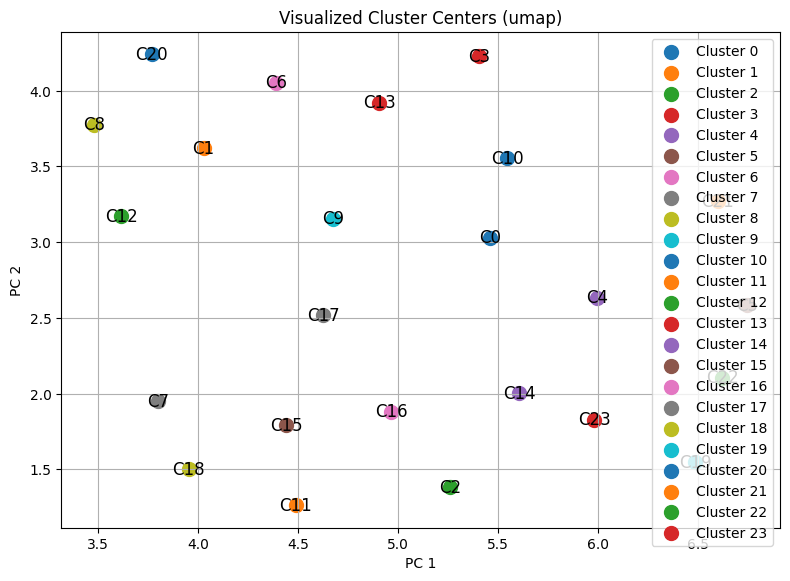

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Use your hardcoded centers
average_cluster_centers = np.array([
    [0.5123761591840695, 0.5140157331579, 0.6831534974004088, 0.7204774058669061, 0.8225254648089647],
    [0.48779725830574533, 0.5435467958623134, 0.6768065501296562, 0.7242425877199045, 0.8238261111572495],
    [0.5007105967402598, 0.5247834251882338, 0.6691357359314883, 0.7430422731875979, 0.8035315877097506],
    [0.49902895348910353, 0.5399598731657869, 0.7030487197812926, 0.7445066681723741, 0.7987594919916083],
    [0.4977362261903686, 0.5083468714182998, 0.6726267154842428, 0.721214976135926, 0.8076099581198809],
    [0.4884711870679988, 0.5133605257825398, 0.6707408995810319, 0.7299384603793274, 0.7886573226639461],
    [0.49143624668147146, 0.5217802923195775, 0.6768242665161911, 0.7313527941511312, 0.8230046133754204],
    [0.5012540259080389, 0.5480342260689715, 0.6547071016448355, 0.7435910383340986, 0.8249949888585748],
    [0.5033067302309308, 0.5368304618120272, 0.679376606027161, 0.7334422213009363, 0.8230467519386728],
    [0.49219984676791245, 0.5075744616589305, 0.7421827728791999, 0.8110671693663107, 0.879376606027161],
    [0.5015368434658745, 0.5045694615623421, 0.6901296461000831, 0.7189710527529679, 0.8239354851907462],
    [0.5045694615623421, 0.5272989243989445, 0.6640598994821089, 0.7569034740768351, 0.8139151898596749],
    [0.492048132048192, 0.5173260411250585, 0.6577276521733121, 0.7171729443845128, 0.837096494798689],
    [0.49165944245127374, 0.5201821865538564, 0.6894656208774953, 0.74062039816108, 0.8186105499999528],
    [0.5252922844200737, 0.5256783672371088, 0.6735947062116875, 0.7341700689886315, 0.8086014527764528],
    [0.49832492618261703, 0.5310361406321694, 0.665775573068458, 0.7446894935865912, 0.8114452357854461],
    [0.5068931566502503, 0.5119116707692596, 0.6758635052391045, 0.7533616645535871, 0.809079933902014],
    [0.5038552201843834, 0.5127176857244022, 0.6842176979099198, 0.7664805764948168, 0.8205914553473485],
    [0.5059143384498593, 0.5263667304418422, 0.6519314263536782, 0.7423482602904299, 0.8158734785830961],
    [0.49701195393905095, 0.5218786160126315, 0.6621055681740348, 0.7289662798901251, 0.7971867871235617],
    [0.49540860393411174, 0.5197152363535674, 0.6660392841348154, 0.7302387771212686, 0.8356577095592042],
    [0.48975174347394074, 0.520950759693998, 0.6998612857978586, 0.7224852359843775, 0.7884137419520472],
    [0.5027767290027819, 0.5154638848735749, 0.6726269734629596, 0.7159567659763031, 0.7962249022583453],
    [0.5191982999819968, 0.5195816875986318, 0.6737009690491179, 0.7304198787511677, 0.8017236370544126]
], dtype=np.float32)

import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
reduced_centers = reducer.fit_transform(average_cluster_centers)

# Plot the centers
plt.figure(figsize=(8, 6))
for i, point in enumerate(reduced_centers):
    plt.scatter(point[0], point[1], label=f"Cluster {i}", s=100)
    plt.text(point[0], point[1], f"C{i}", fontsize=12, ha='center', va='center')


plt.title("Visualized Cluster Centers (umap)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



--- Setting up Classification Model ---
✅ Keras model loaded successfully. Expects input shape: (224, 224)

--- Starting Anomaly & Inlier Validation ---
Calculating original cluster centers...
Computed centers for 2 clusters.

Processing folder: C:\Users\User\Downloads\Skin-disease-dataset\new_disease_2
  Processing image 630/630: aug_9_93_BA-impetigo (71).jpggg
✅ Processed 630 images.

Processing folder: C:\Users\User\Downloads\Skin-disease-dataset\known_disease
  Processing image 555/555: aug_94_45_FU-ringworm (21).jpggg87.jpgg
✅ Processed 555 images.

--- Validation Report for: Potential Anomaly Folder ---
Total Images Processed: 630
Distance Threshold      : > 35.00
Confidence Threshold    : < 0.80 (80%)
---
Images failing CONFIDENCE check: 285
Images failing DISTANCE check  : 620
---
🎯 Anomalies Detected (failed BOTH checks): 280 (44.44%)
--------------------------------------------------

--- Validation Report for: Known Inlier Folder ---
Total Images Processed: 555
Distance Thr

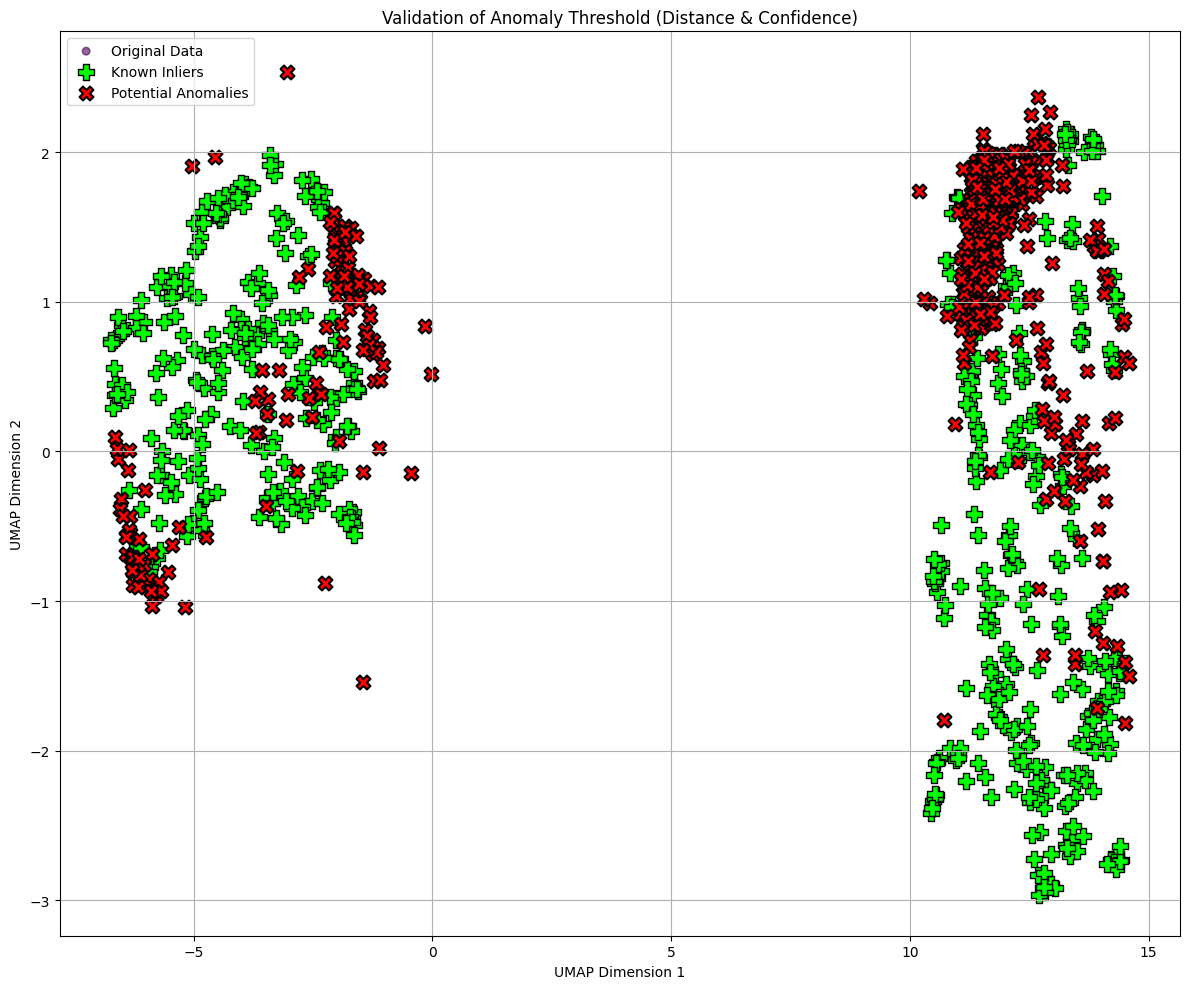

In [14]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

# Assume 'features', 'hdb_labels', and 'umap_model' are already defined and fitted
# from your previous steps. 'extract_features_both' is also assumed to be defined.

# ==============================================================================
# === Step 8.5: NEW - Classification Model Setup ===
# ==============================================================================
print("\n--- Setting up Classification Model ---")

# --- Configuration for Classification ---
# IMPORTANT: Change this to the correct path of your .h5 model file
model_path = r"four_skin_disease_detection.h5" 
confidence_threshold = 0.80 # 80% confidence
# --- End Configuration ---

# Load the pre-trained Keras model
try:
    classification_model = tf.keras.models.load_model(model_path)
    # The model's expected input shape (e.g., (224, 224)) is read automatically
    input_shape = tuple(classification_model.input_shape[1:3]) 
    print(f"✅ Keras model loaded successfully. Expects input shape: {input_shape}")
except Exception as e:
    print(f"🚨 CRITICAL ERROR: Could not load the Keras model from '{model_path}'.")
    print(f"   Please check the path. Anomaly detection will not use confidence scores.")
    print(f"   Error details: {e}")
    classification_model = None # Set to None to handle errors gracefully
    input_shape = (224, 224) # Provide a default shape

# ==============================================================================
# === Step 9: Anomaly Detection Setup (Unchanged) ===
# ==============================================================================
print("\n--- Starting Anomaly & Inlier Validation ---")

# --- Configuration ---
potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease_2" 
known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\known_disease" 
anomaly_threshold = 35.0 # The distance threshold
# --- End Configuration ---

print("Calculating original cluster centers...")
unique_labels = np.unique(hdb_labels)
cluster_centers = {}
original_inlier_features = features[hdb_labels != -1]
original_inlier_labels = hdb_labels[hdb_labels != -1]

for label in unique_labels:
    if label == -1:
        continue
    cluster_features = original_inlier_features[original_inlier_labels == label]
    center = cluster_features.mean(axis=0)
    cluster_centers[label] = center
print(f"Computed centers for {len(cluster_centers)} clusters.")

# ==============================================================================
# === Step 10: MODIFIED - Reusable Functions to Process and Report ===
# ==============================================================================

# --- NEW Helper Function to Get Model Confidence ---
def predict_confidence(image_path, model, target_size):
    """Loads an image, preprocesses it, and returns the model's top confidence score."""
    if model is None:
        return 1.0 # Return a high confidence if model is not available to avoid false positives

    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(target_size)
        img_array = np.array(img) / 255.0 # Normalize to [0, 1]
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
        
        # Get prediction probabilities and return the highest one (the confidence)
        predictions = model.predict(img_array, verbose=0) 
        return np.max(predictions)
    except Exception as e:
        print(f"⚠️ Warning: Could not process {os.path.basename(image_path)} for classification. Error: {e}")
        return 1.0 # Return high confidence on error

# --- MODIFIED Function to Process a Folder ---
def process_and_evaluate_folder(folder_path, cluster_centers, dist_thresh, conf_model, conf_thresh, model_input_shape):
    """Processes images, checks for anomalies using BOTH distance and confidence, and returns results."""
    print(f"\nProcessing folder: {folder_path}")
    if not os.path.exists(folder_path):
        print(f"⚠️ ERROR: Folder not found. Skipping.")
        return [], []

    features_list, results_list = [], []
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    
    for i, fname in enumerate(image_files):
        print(f"  Processing image {i+1}/{len(image_files)}: {fname}", end='\r')
        path = os.path.join(folder_path, fname)
        
        # 1. Extract features for distance calculation
        feat = extract_features_both(path)
        features_list.append(feat)

        # 2. Calculate distance to nearest cluster
        distances = [np.linalg.norm(feat - center) for center in cluster_centers.values()]
        min_distance = min(distances) if distances else float('inf')
        
        # 3. Get prediction confidence from the .h5 model
        confidence = predict_confidence(path, conf_model, model_input_shape)

        # 4. MODIFIED LOGIC: Anomaly requires BOTH high distance AND low confidence
        is_anomaly = (min_distance > dist_thresh) and (confidence < conf_thresh)
        
        results_list.append({
            "filename": fname,
            "min_distance": min_distance,
            "confidence": confidence,
            "is_anomaly": is_anomaly
        })
        
    print(f"\n✅ Processed {len(features_list)} images.")
    return np.array(features_list, dtype=np.float64), results_list

# --- MODIFIED Function to Print a Detailed Report ---
def print_report(folder_name, results_list, dist_thresh, conf_thresh):
    """Prints a formatted, detailed report from the evaluation results."""
    if not results_list:
        return
        
    total_count = len(results_list)
    anomalies = [item for item in results_list if item["is_anomaly"]]
    low_confidence_count = sum(1 for item in results_list if item["confidence"] < conf_thresh)
    far_distance_count = sum(1 for item in results_list if item["min_distance"] > dist_thresh)
    anomaly_count = len(anomalies)
    anomaly_percentage = (anomaly_count / total_count) * 100 if total_count > 0 else 0

    print(f"\n--- Validation Report for: {folder_name} ---")
    print(f"Total Images Processed: {total_count}")
    print(f"Distance Threshold      : > {dist_thresh:.2f}")
    print(f"Confidence Threshold    : < {conf_thresh:.2f} ({(conf_thresh * 100):.0f}%)")
    print("---")
    print(f"Images failing CONFIDENCE check: {low_confidence_count}")
    print(f"Images failing DISTANCE check  : {far_distance_count}")
    print("---")
    print(f"🎯 Anomalies Detected (failed BOTH checks): {anomaly_count} ({anomaly_percentage:.2f}%)")
    print("--------------------------------------------------")

# ==============================================================================
# === Step 11: MODIFIED - Process Both Folders and Report ===
# ==============================================================================
# Process the potential anomalies
anomaly_features, anomaly_results = process_and_evaluate_folder(
    potential_anomaly_folder,
    cluster_centers,
    anomaly_threshold,
    classification_model,
    confidence_threshold,
    input_shape
)
# Process the known inliers
inlier_features, inlier_results = process_and_evaluate_folder(
    known_inlier_folder,
    cluster_centers,
    anomaly_threshold,
    classification_model,
    confidence_threshold,
    input_shape
)

# Print the detailed reports for both
print_report("Potential Anomaly Folder", anomaly_results, anomaly_threshold, confidence_threshold)
print_report("Known Inlier Folder", inlier_results, anomaly_threshold, confidence_threshold)

# ==============================================================================
# === Step 12: Combined Visualization (Unchanged) ===
# ==============================================================================
print("\nGenerating combined visualization...")
# Use the FITTED umap_model to transform the new data
anomaly_embeddings = umap_model.transform(anomaly_features) if len(anomaly_features) > 0 else np.array([])
inlier_embeddings = umap_model.transform(inlier_features) if len(inlier_features) > 0 else np.array([])

plt.figure(figsize=(12, 10))

# 1. Plot the original data
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdb_labels, 
            cmap='viridis', s=30, alpha=0.6, label='Original Data')

# 2. Plot the new images from the "Known Inlier" folder
if len(inlier_embeddings) > 0:
    plt.scatter(inlier_embeddings[:, 0], inlier_embeddings[:, 1], 
                c='lime', marker='P', s=120, label='Known Inliers', 
                edgecolors='black', linewidth=1)

# 3. Plot the new images from the "Anomaly" folder
if len(anomaly_embeddings) > 0:
    plt.scatter(anomaly_embeddings[:, 0], anomaly_embeddings[:, 1], 
                c='red', marker='X', s=100, label='Potential Anomalies', 
                edgecolors='black', linewidth=1.5)

plt.title("Validation of Anomaly Threshold (Distance & Confidence)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## KNN using different models

Loading pretrained models...
Extracting features...
✅ Extracted combined features for 3780 images.
Fitting KNN classifier...
✅ Images grouped by KNN class saved.
Visualizing with PCA...


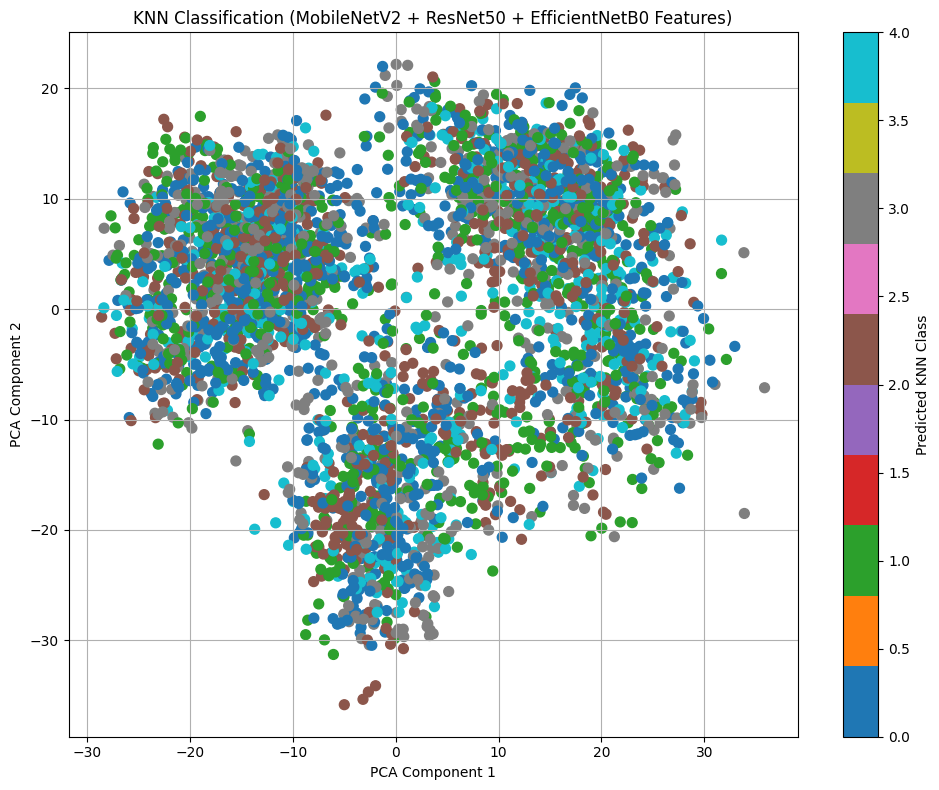

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input as mobilenet_preprocess
)

from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    preprocess_input as resnet_preprocess
)

from tensorflow.keras.applications.efficientnet import (
    EfficientNetB0,
    preprocess_input as effnet_preprocess
)
import shutil
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder

# === Config ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
output_dir = "knn_grouped_images"
num_classes = 5  # Assuming 5-class KNN classification
k_neighbors = 5

# === Step 1: Load Models ===
print("Loading pretrained models...")
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
effnet_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')

# === Step 2: Feature Extraction ===
def extract_combined_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    arr = image.img_to_array(img)
    arr_exp = np.expand_dims(arr, axis=0)

    feat1 = mobilenet_model.predict(mobilenet_preprocess(arr_exp.copy()), verbose=0)[0]
    feat2 = resnet_model.predict(resnet_preprocess(arr_exp.copy()), verbose=0)[0]
    feat3 = effnet_model.predict(effnet_preprocess(arr_exp.copy()), verbose=0)[0]
    
    return np.concatenate([feat1, feat2, feat3])

# === Step 3: Load and Extract Features ===
print("Extracting features...")
features = []
filenames = []

for fname in os.listdir(image_folder):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(image_folder, fname)
        feat = extract_combined_features(path)
        features.append(feat)
        filenames.append(fname)

features = np.array(features, dtype=np.float64)
print(f"✅ Extracted combined features for {len(filenames)} images.")

# === Step 4: Dummy Labels (You should replace this with actual labels if available) ===
# For demo: evenly distribute 5 classes
labels = [i % num_classes for i in range(len(filenames))]
label_names = [f"Class_{i}" for i in labels]

# === Step 5: KNN Classification ===
print("Fitting KNN classifier...")
knn = KNeighborsClassifier(n_neighbors=k_neighbors)
knn.fit(features, labels)
predicted_labels = knn.predict(features)

# === Step 6: Save Grouped Images ===
# print(f"Saving images grouped by predicted KNN class into: {output_dir}")
# os.makedirs(output_dir, exist_ok=True)

# for fname, pred_label in zip(filenames, predicted_labels):
#     class_name = f"class_{pred_label}"
#     class_path = os.path.join(output_dir, class_name)
#     os.makedirs(class_path, exist_ok=True)
    
#     src = os.path.join(image_folder, fname)
#     dst = os.path.join(class_path, fname)
#     shutil.copy(src, dst)

print("✅ Images grouped by KNN class saved.")

# === Step 7: PCA + Scatter Plot ===
print("Visualizing with PCA...")
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=predicted_labels, cmap='tab10', s=50)
plt.title("KNN Classification (MobileNetV2 + ResNet50 + EfficientNetB0 Features)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Predicted KNN Class")
plt.grid(True)
plt.tight_layout()
plt.show()


Loading models...
Extracting features...
✅ Extracted features for 3780 images per model.
Clustering MobileNetV2 features with KMeans...


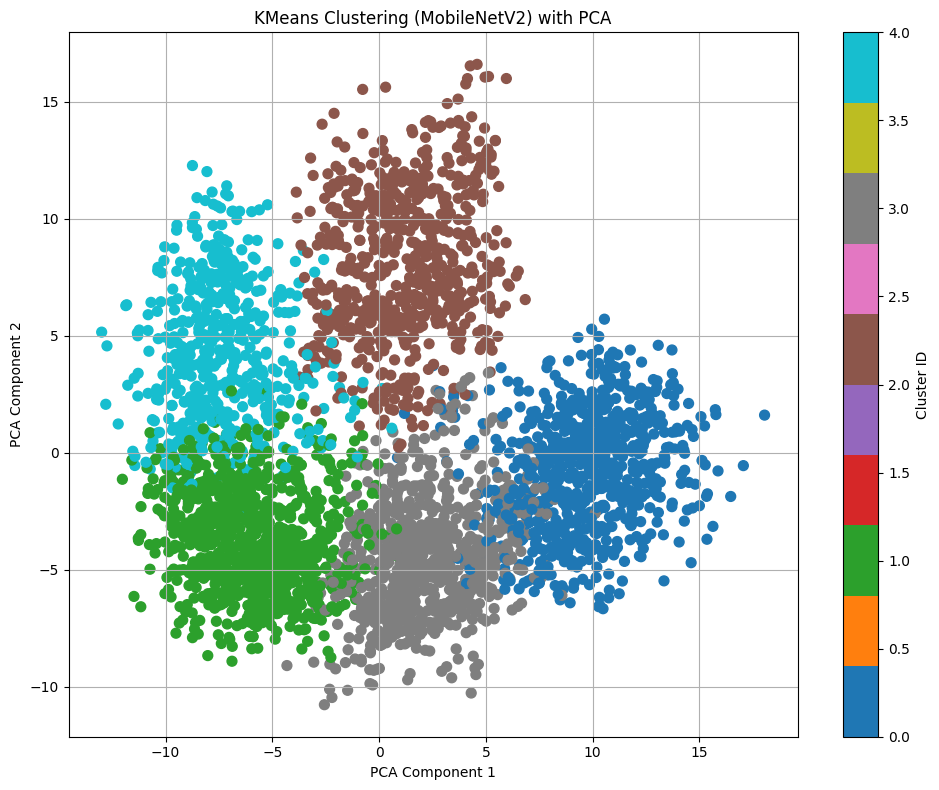

Clustering ResNet50 features with KMeans...


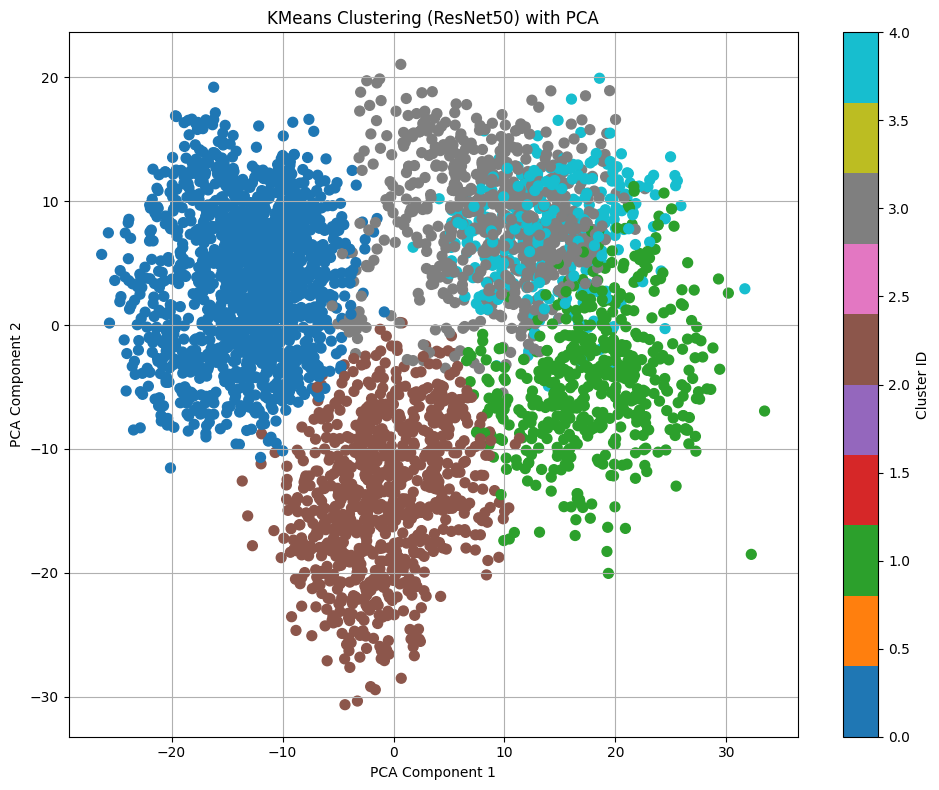

Clustering EfficientNetB0 features with KMeans...


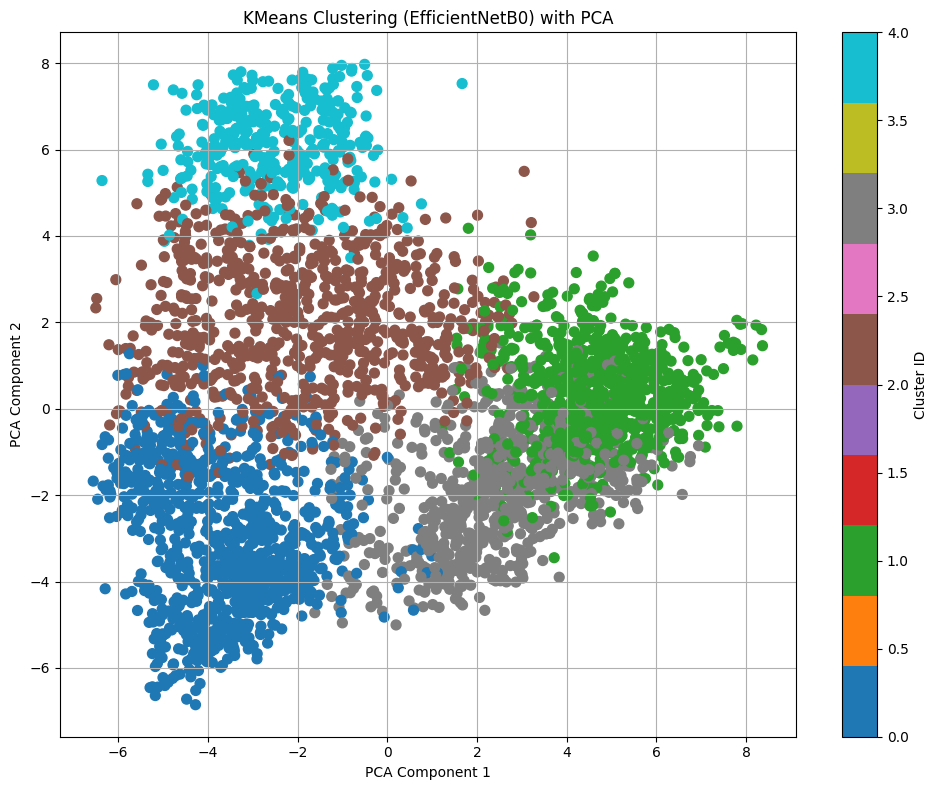

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input as mobilenet_preprocess
)

from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    preprocess_input as resnet_preprocess
)

from tensorflow.keras.applications.efficientnet import (
    EfficientNetB0,
    preprocess_input as effnet_preprocess
)

# === Config ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
num_clusters = 5

# === Load Models ===
print("Loading models...")
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')
effnet = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')

# === Feature Extraction ===
def extract_features(model, preprocess_fn, img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_fn(arr)
    return model.predict(arr, verbose=0)[0]

features_mobilenet, features_resnet, features_effnet, filenames = [], [], [], []

print("Extracting features...")
for fname in os.listdir(image_folder):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        path = os.path.join(image_folder, fname)
        filenames.append(fname)

        features_mobilenet.append(extract_features(mobilenet, mobilenet_preprocess, path))
        features_resnet.append(extract_features(resnet, resnet_preprocess, path))
        features_effnet.append(extract_features(effnet, effnet_preprocess, path))

features_mobilenet = np.array(features_mobilenet)
features_resnet = np.array(features_resnet)
features_effnet = np.array(features_effnet)

print(f"✅ Extracted features for {len(filenames)} images per model.")

# === Cluster + Visualize ===
def cluster_and_visualize(features, model_name):
    print(f"Clustering {model_name} features with KMeans...")
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(features)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(features)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='tab10', s=50)
    plt.title(f"KMeans Clustering ({model_name}) with PCA")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(scatter, label="Cluster ID")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run for each model
cluster_and_visualize(features_mobilenet, "MobileNetV2")
cluster_and_visualize(features_resnet, "ResNet50")
cluster_and_visualize(features_effnet, "EfficientNetB0")


Loading models...
✅ Models loaded.
Extracting features from initial dataset...
✅ Extracted initial features for 3780 images per model.

==================== Running Analysis for: MobileNetV2 ====================
Clustering original MobileNetV2 features with KMeans...
Computed 5 cluster centers.

Processing folder: new_disease_2
✅ Processed 630 images.

Processing folder: known_diseases_folder
⚠️ ERROR: Folder not found at C:\path\to\your\known_diseases_folder. Skipping.

--- Validation Report for: Potential Anomaly Folder (MobileNetV2) ---
Total Images: 630
Anomaly Threshold: 30.0
Anomalies Detected (> threshold): 0 (0.00%)
Inliers Detected (<= threshold): 630 (100.00%)
--------------------------------------------------
Generating combined visualization...


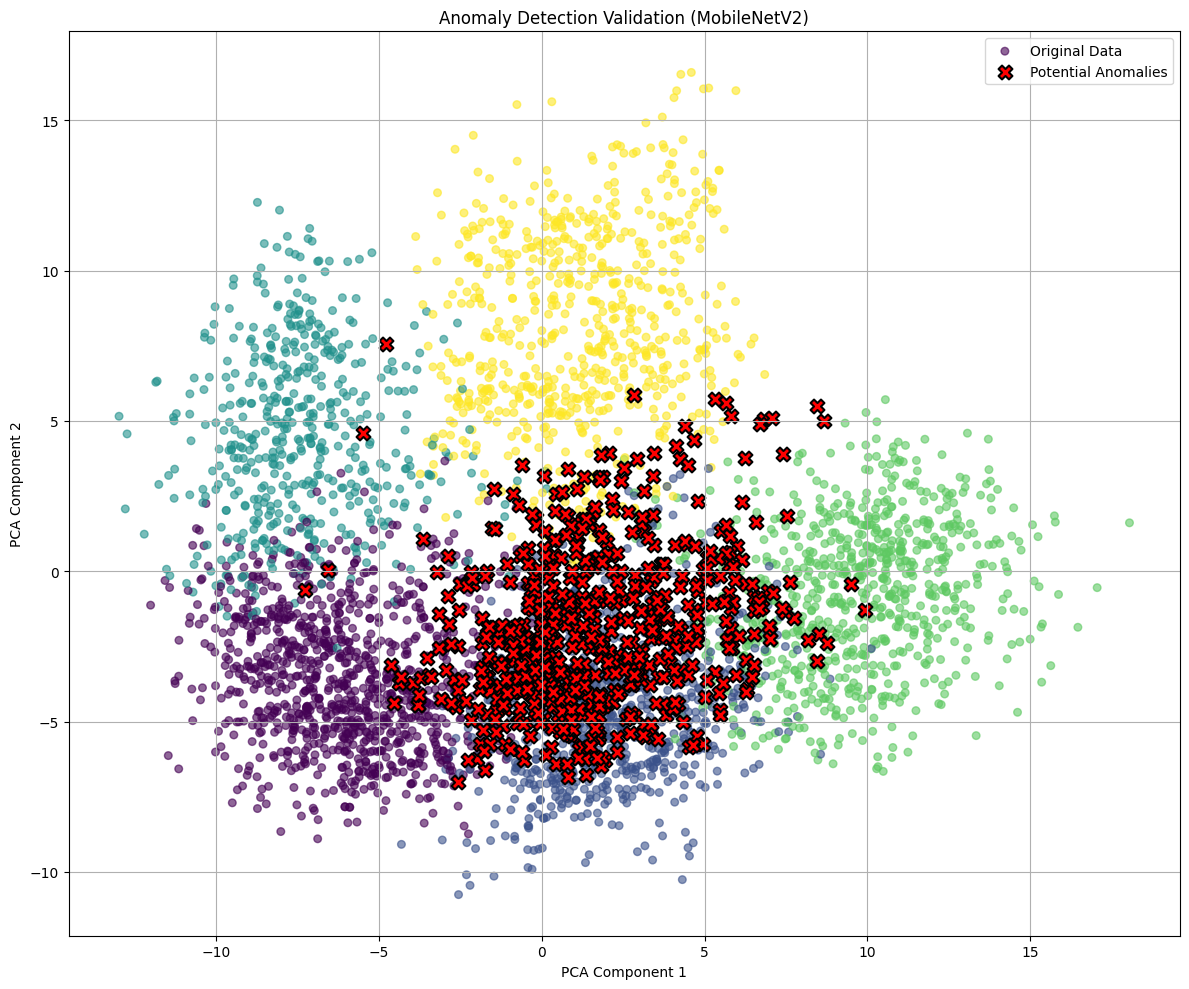


==================== Running Analysis for: ResNet50 ====================
Clustering original ResNet50 features with KMeans...
Computed 5 cluster centers.

Processing folder: new_disease_2
✅ Processed 630 images.

Processing folder: known_diseases_folder
⚠️ ERROR: Folder not found at C:\path\to\your\known_diseases_folder. Skipping.

--- Validation Report for: Potential Anomaly Folder (ResNet50) ---
Total Images: 630
Anomaly Threshold: 30.0
Anomalies Detected (> threshold): 301 (47.78%)
Inliers Detected (<= threshold): 329 (52.22%)
--------------------------------------------------
Generating combined visualization...


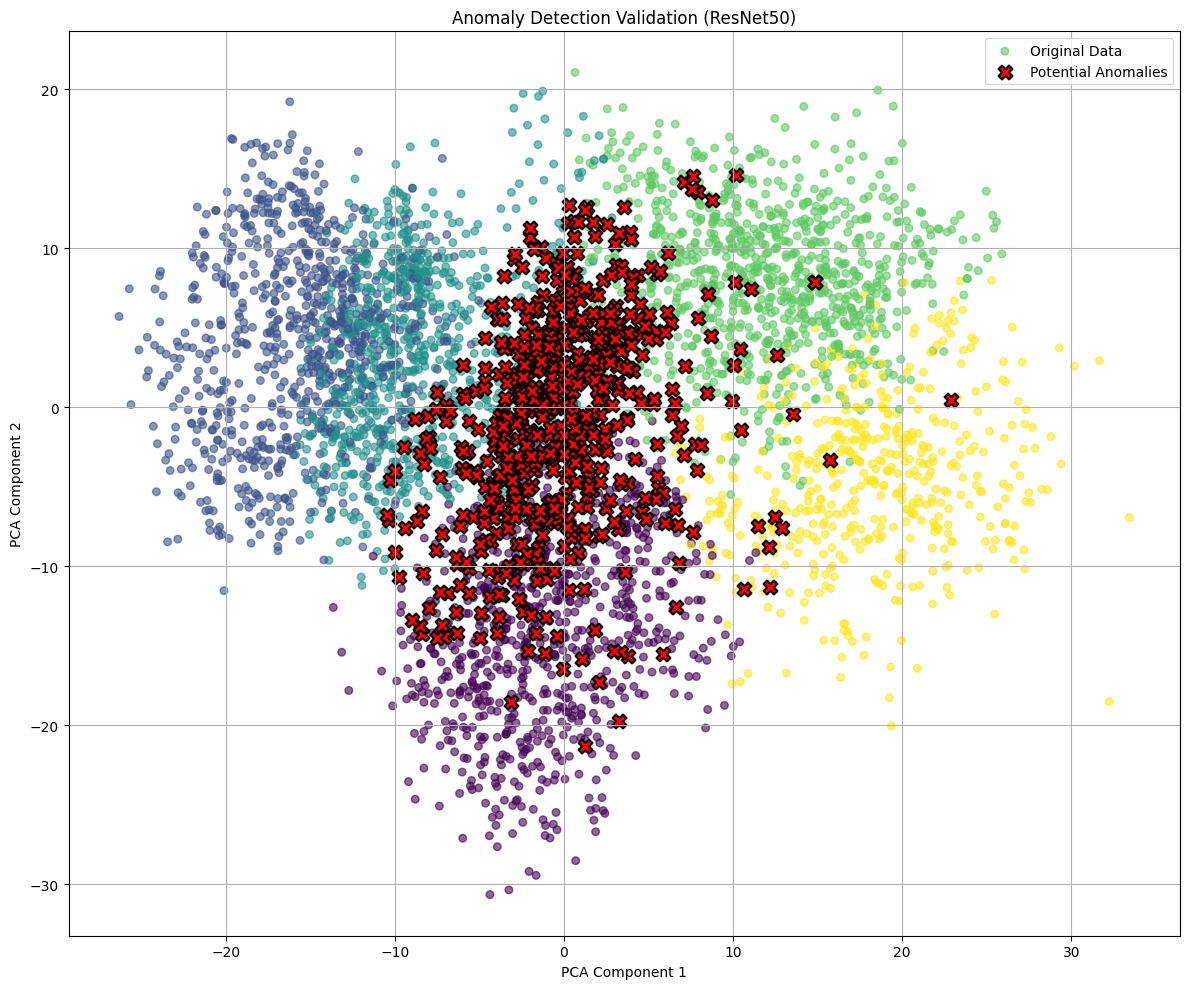


==================== Running Analysis for: EfficientNetB0 ====================
Clustering original EfficientNetB0 features with KMeans...
Computed 5 cluster centers.

Processing folder: new_disease_2
✅ Processed 630 images.

Processing folder: known_diseases_folder
⚠️ ERROR: Folder not found at C:\path\to\your\known_diseases_folder. Skipping.

--- Validation Report for: Potential Anomaly Folder (EfficientNetB0) ---
Total Images: 630
Anomaly Threshold: 30.0
Anomalies Detected (> threshold): 0 (0.00%)
Inliers Detected (<= threshold): 630 (100.00%)
--------------------------------------------------
Generating combined visualization...


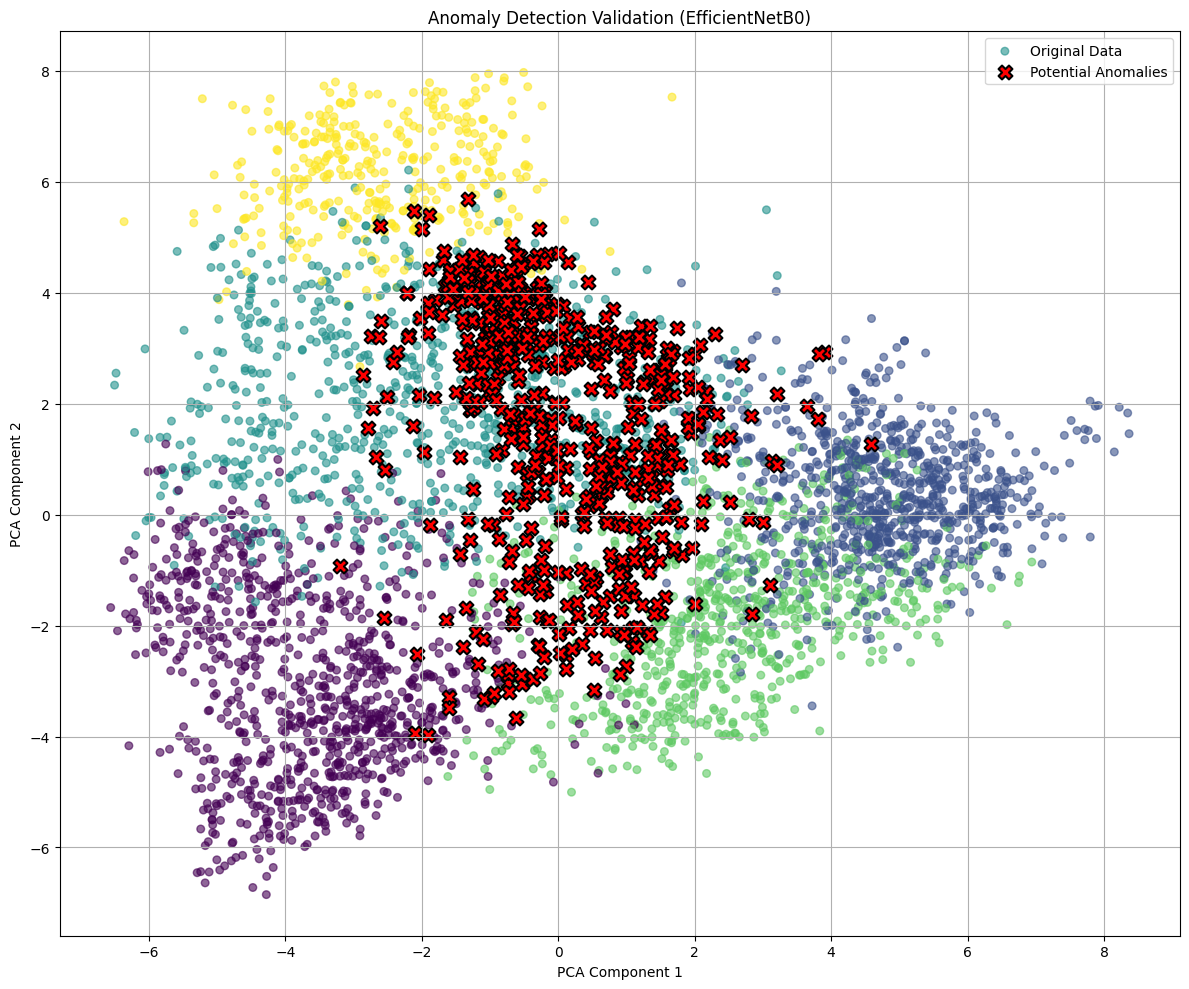


🎉 Analysis complete.


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input as mobilenet_preprocess
)
from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    preprocess_input as resnet_preprocess
)
from tensorflow.keras.applications.efficientnet import (
    EfficientNetB0,
    preprocess_input as effnet_preprocess
)

# === Main Configuration ===
image_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\mixed-small"
num_clusters = 5

# --- Anomaly Detection Configuration ---
# ⚠️ IMPORTANT: Update these paths to your folders
potential_anomaly_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\new_disease_2" # Folder with images expected to be ANOMALIES
known_inlier_folder = r"C:\Users\User\Downloads\Skin-disease-dataset\known_disease" # Folder with images expected to be INLIERS (similar to original set)
anomaly_threshold = 30.0 # The distance threshold for classifying an anomaly. You may need to tune this.

# === Load Models ===
print("Loading models...")
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')
effnet = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')
print("✅ Models loaded.")

# === Feature Extraction Function ===
def extract_features(model, preprocess_fn, img_path):
    """Extracts features from a single image using a given model."""
    img = image.load_img(img_path, target_size=(224, 224))
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_fn(arr)
    return model.predict(arr, verbose=0)[0]

# === Extract Features for Initial Dataset ===
features_mobilenet, features_resnet, features_effnet, filenames = [], [], [], []
print("Extracting features from initial dataset...")
for fname in os.listdir(image_folder):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        path = os.path.join(image_folder, fname)
        filenames.append(fname)
        
        # Extract for each model
        features_mobilenet.append(extract_features(mobilenet, mobilenet_preprocess, path))
        features_resnet.append(extract_features(resnet, resnet_preprocess, path))
        features_effnet.append(extract_features(effnet, effnet_preprocess, path))

features_mobilenet = np.array(features_mobilenet)
features_resnet = np.array(features_resnet)
features_effnet = np.array(features_effnet)
print(f"✅ Extracted initial features for {len(filenames)} images per model.")

# =========================================================
# === Anomaly Detection & Validation (New Section) ===
# =========================================================

def process_folder_for_anomaly_check(folder_path, model, preprocess_fn, cluster_centers, threshold):
    """Processes all images in a folder, checks for anomalies, and returns features and results."""
    print(f"\nProcessing folder: {os.path.basename(folder_path)}")
    if not os.path.exists(folder_path):
        print(f"⚠️ ERROR: Folder not found at {folder_path}. Skipping.")
        return np.array([]), []

    features_list, results_list = [], []
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for fname in image_files:
        path = os.path.join(folder_path, fname)
        # Extract features for the new image
        feat = extract_features(model, preprocess_fn, path)
        features_list.append(feat)

        # Calculate the minimum distance to any cluster center
        distances = [np.linalg.norm(feat - center) for center in cluster_centers]
        min_distance = min(distances) if distances else float('inf')
        
        results_list.append({
            "filename": fname,
            "min_distance": min_distance,
            "is_anomaly": min_distance > threshold
        })
    print(f"✅ Processed {len(features_list)} images.")
    return np.array(features_list), results_list

def print_validation_report(folder_name, results_list, threshold):
    """Prints a formatted report from the evaluation results."""
    if not results_list:
        return
        
    total_count = len(results_list)
    anomaly_count = sum(1 for item in results_list if item["is_anomaly"])
    inlier_count = total_count - anomaly_count
    
    anomaly_percentage = (anomaly_count / total_count) * 100 if total_count > 0 else 0
    inlier_percentage = (inlier_count / total_count) * 100 if total_count > 0 else 0

    print(f"\n--- Validation Report for: {folder_name} ---")
    print(f"Total Images: {total_count}")
    print(f"Anomaly Threshold: {threshold}")
    print(f"Anomalies Detected (> threshold): {anomaly_count} ({anomaly_percentage:.2f}%)")
    print(f"Inliers Detected (<= threshold): {inlier_count} ({inlier_percentage:.2f}%)")
    print("--------------------------------------------------")

def run_anomaly_detection_for_model(model, preprocess_fn, model_name, original_features, threshold):
    """
    Performs clustering, anomaly detection, reporting, and visualization for a single model.
    """
    print(f"\n{'='*20} Running Analysis for: {model_name} {'='*20}")
    
    # === Step 1: Cluster original data and get centers ===
    print(f"Clustering original {model_name} features with KMeans...")
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    original_labels = kmeans.fit_predict(original_features)
    cluster_centers = kmeans.cluster_centers_
    print(f"Computed {len(cluster_centers)} cluster centers.")
    
    # === Step 2: Fit PCA on original data for visualization ===
    pca = PCA(n_components=2, random_state=42)
    original_reduced = pca.fit_transform(original_features)

    # === Step 3: Process potential anomalies and known inliers ===
    anomaly_features, anomaly_results = process_folder_for_anomaly_check(
        potential_anomaly_folder, model, preprocess_fn, cluster_centers, threshold
    )
    inlier_features, inlier_results = process_folder_for_anomaly_check(
        known_inlier_folder, model, preprocess_fn, cluster_centers, threshold
    )
    
    # === Step 4: Print reports ===
    print_validation_report(f"Potential Anomaly Folder ({model_name})", anomaly_results, threshold)
    print_validation_report(f"Known Inlier Folder ({model_name})", inlier_results, threshold)

    # === Step 5: Combined Visualization ===
    print("Generating combined visualization...")
    
    # Use the FITTED pca model to transform the new data
    anomaly_reduced = pca.transform(anomaly_features) if len(anomaly_features) > 0 else np.array([])
    inlier_reduced = pca.transform(inlier_features) if len(inlier_features) > 0 else np.array([])

    plt.figure(figsize=(12, 10))
    # 1. Plot the original data clusters
    plt.scatter(original_reduced[:, 0], original_reduced[:, 1], c=original_labels, 
                cmap='viridis', s=30, alpha=0.6, label='Original Data')
    
    # 2. Plot the new images from the "Known Inlier" folder
    if len(inlier_reduced) > 0:
        plt.scatter(inlier_reduced[:, 0], inlier_reduced[:, 1], 
                    c='lime', marker='P', s=120, label='Known Inliers (Validation)', 
                    edgecolors='black', linewidth=1)

    # 3. Plot the new images from the "Anomaly" folder
    if len(anomaly_reduced) > 0:
        plt.scatter(anomaly_reduced[:, 0], anomaly_reduced[:, 1], 
                    c='red', marker='X', s=100, label='Potential Anomalies', 
                    edgecolors='black', linewidth=1.5)

    plt.title(f"Anomaly Detection Validation ({model_name})")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Run the full analysis for each model ===
run_anomaly_detection_for_model(mobilenet, mobilenet_preprocess, "MobileNetV2", features_mobilenet, anomaly_threshold)
run_anomaly_detection_for_model(resnet, resnet_preprocess, "ResNet50", features_resnet, anomaly_threshold)
run_anomaly_detection_for_model(effnet, effnet_preprocess, "EfficientNetB0", features_effnet, anomaly_threshold)

print("\n🎉 Analysis complete.")